In [10]:
import os,sys
sys.path.append(os.path.dirname(os.getcwd()))
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["XLA_PYTHON_CLIENT_ALLOCATOR"] = "platform"
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

In [11]:
from functools import partial
from typing import Any, Sequence

# activate TPUs if available
try:
    import jax.tools.colab_tpu
    jax.tools.colab_tpu.setup_tpu()
except (KeyError, RuntimeError):
    print("TPU not found, continuing without it.")

from jax import config
config.update("jax_enable_x64", True)

import jax
from jax import numpy as jnp
from jax import random
from jax import vmap
from jax.tree_util import Partial, tree_map

from jaxopt import LBFGS, GradientDescent
from jaxopt import linear_solve
from jaxopt import OptaxSolver
from jaxopt import tree_util

import optax

# we use flax to construct a small multi-layer perceptron
from flax import linen as nn
from tqdm.auto import tqdm

# for plotting
import matplotlib.pyplot as plt
from matplotlib.pyplot import cm

TPU not found, continuing without it.


In [12]:
# import scienceplots
# plt.style.use(["science", "grid"])
%matplotlib inline

# Default setting
import matplotlib as mpl
import matplotlib
# import seaborn as sns
from matplotlib import cm
from cycler import cycler

# mpl.rcParams['axes.prop_cycle'] = cycler(color='brgcmyk')
# grid setting
plt.rcParams['axes.grid'] = False
plt.rcParams['grid.color'] = '#808080'
plt.rcParams['grid.linestyle'] = '--'
plt.rcParams['grid.linewidth'] = 0.5

# graph font size
# mpl.rcParams['font.size'] = 16
mpl.rcParams['legend.fontsize'] = 16
mpl.rcParams['figure.titlesize'] = 18
mpl.rcParams['axes.titlesize'] = 18
mpl.rcParams['lines.linewidth'] = 2.0
mpl.rcParams['axes.labelsize'] = 18
mpl.rcParams['xtick.labelsize'] = 14
mpl.rcParams['ytick.labelsize'] = 14

# tight axis
plt.rcParams['axes.xmargin'] = 0

# figure size
plt.rcParams["figure.figsize"] = (6.4, 4.8)

# LaTeX
# plt.rcParams['text.usetex'] = True
# plt.rcParams["font.family"] = "sans-serif"
# plt.rcParams["font.sans-serif"] = ["Helvetica", "Arial"]
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['pdf.fonttype'] = 42 # For TrueType fonts

In [13]:
# graph font size
# mpl.rcParams['font.size'] = 16
mpl.rcParams['legend.fontsize'] = 7
mpl.rcParams['figure.titlesize'] = 8
mpl.rcParams['axes.titlesize'] = 8
mpl.rcParams['lines.linewidth'] = 1.0
mpl.rcParams['axes.labelsize'] = 10
mpl.rcParams['xtick.labelsize'] = 7
mpl.rcParams['ytick.labelsize'] = 7

In [14]:
import jax.numpy as jnp
import jax
import pickle
import time
from jax import hessian, jacobian, jit, vmap, grad, random, value_and_grad
from functools import partial
import diffrax
from typing import Callable, Optional, Union
from flax import linen as nn
from flax.training.train_state import TrainState
import optax
from jax_md.quantity import force
import equinox as eqx
from tqdm import trange, tqdm

In [15]:
from blockymetamaterials.utils import SolutionType, SolutionData, ControlParams, GeometricalParams, MechanicalParams, LigamentParams, ContactParams
from blockymetamaterials.geometry import Geometry, QuadGeometry, compute_inertia, compute_edge_angles, compute_edge_lengths, DOFsInfo, QuadGeometry_InputSource
from blockymetamaterials.energy import build_strain_energy, kinetic_energy, ligament_energy, ligament_energy_linearized, build_contact_energy, combine_block_energies, compute_ligament_strains_history, constrain_energy
from typing import Any, Literal, Optional, List, Union, Tuple, Dict
import dataclasses
from dataclasses import dataclass
from itertools import combinations
from cooptimization_real import setup_dynamic_solver, setup_dynamic_solver_all

In [16]:
color_list = ["#2980b9", "#e74c3c", "#00a043", "#793693", "#f1c40f","#fb9206"]

In [17]:
from collect_result_figures import minmax_scaler, TimeSeriesCNN, train_nn

In [18]:
ts = jnp.linspace(0, 1.0, 200)

In [19]:

def show_results_band(fname_list, ts, N=4, save_fig=False, folder="4_input_source", name="", idx_list=None, source_num=4):
    if idx_list is None:
        idx_list = [f"File {k}" for k in range(len(fname_list))]

    for i in range(N):
        # Collect predictions from all files
        list_pred_init = []
        list_pred_opt = []
        test_output_i = None
        n_source = None

        for k in range(len(fname_list)):
            
            filename = f"Simulation/input_source_{source_num}_training_dataset_measure_idx_{idx_list[k]}.pickle"
            print("Checking for data file at:", filename)
            with open(filename, "rb") as f:
                record_dict = pickle.load(f)
            
            mm_scaler = minmax_scaler(record_dict["input_data"], record_dict["output_data"])

            fname = fname_list[k]
            with open(fname, "rb") as f:
                record_dict = pickle.load(f)

            train_data, train_output, test_data, test_output = record_dict["initial_data"]
            params = record_dict["nn_record"][0][0]
            model = TimeSeriesCNN(output_features=train_output.shape[-1])

            train_data_normalized, train_output_normalized = mm_scaler.transform(train_data, train_output)
            test_data_normalized, test_output_normalized = mm_scaler.transform(test_data, test_output)
            pred_y_test = model.apply(params, test_data_normalized)
            _, pred_y_test_org = mm_scaler.inverse_transform(test_data, pred_y_test)

            train_data, train_output, test_data, test_output = record_dict["optimal_data"]
            opt_idx = jnp.argmin(jnp.array(record_dict["loss_record"]))
            opt_params = record_dict["nn_record"][opt_idx][0]
            train_data_normalized, train_output_normalized = mm_scaler.transform(train_data, train_output)
            test_data_normalized, test_output_normalized = mm_scaler.transform(test_data, test_output)
            pred_y_test_opt = model.apply(opt_params, test_data_normalized)
            _, pred_y_test_opt_org = mm_scaler.inverse_transform(test_data, pred_y_test_opt)

            list_pred_init.append(pred_y_test_org)
            list_pred_opt.append(pred_y_test_opt_org)
            if k == 0:
                test_output_i = test_output
            n_source = train_output.shape[-1]

        pred_init_array = jnp.stack(list_pred_init, axis=0)
        pred_opt_array = jnp.stack(list_pred_opt, axis=0)

        mean_pred_init = jnp.mean(pred_init_array, axis=0)
        std_pred_init = jnp.std(pred_init_array, axis=0)
        mean_pred_opt = jnp.mean(pred_opt_array, axis=0)
        std_pred_opt = jnp.std(pred_opt_array, axis=0)

        min_value = float(jnp.min(test_output_i[i, :, :]) * 1.5)

        # Figure 1: Initial design – mean prediction with std band
        plt.figure(figsize=(10, 1.6 * n_source))
        for j in range(n_source):
            plt.subplot(n_source // 2, 2, 1 + j)
            true_signal = -test_output_i[i, :, j]
            mean_signal = -mean_pred_init[i, :, j]
            std_signal = std_pred_init[i, :, j]

            plt.plot(ts, true_signal, "-", color=color_list[0], label="True")
            plt.plot(ts, mean_signal, "-", color=color_list[1], label="Mean prediction")
            plt.fill_between(
                ts,
                mean_signal - std_signal,
                mean_signal + std_signal,
                color=color_list[1],
                alpha=0.25,
                label="Std dev",
            )
            plt.xlim(0, 0.4)
            plt.ylim(-5e-2, -min_value)
            plt.ylabel(f"Input {j+1}")
        plt.suptitle(f"{name} Test {i} (Initial design)")
        # plt.legend()
        plt.tight_layout()
        if save_fig:
            plt.savefig(f"Figure/{folder}/{name}Test_{i}_init.eps", bbox_inches="tight")
        plt.show()

        # Figure 2: Optimized design – mean prediction with std band
        plt.figure(figsize=(10, 1.5 * n_source))
        for j in range(n_source):
            plt.subplot(n_source // 2, 2, 1 + j)
            true_signal = -test_output_i[i, :, j]
            mean_signal = -mean_pred_opt[i, :, j]
            std_signal = std_pred_opt[i, :, j]

            plt.plot(ts, true_signal, "-", color=color_list[0], label="True")
            plt.plot(ts, mean_signal, "-", color=color_list[2], label="Mean prediction (optimized)")
            plt.fill_between(
                ts,
                mean_signal - std_signal,
                mean_signal + std_signal,
                color=color_list[2],
                alpha=0.25,
                label="Std dev",
            )
            plt.xlim(0, 0.4)
            plt.ylim(-5e-2, -min_value)
            plt.ylabel(f"Input {j+1}")
        plt.suptitle(f"{name} Test {i} (Optimized design)")
        # plt.legend()
        plt.tight_layout()
        if save_fig:
            plt.savefig(f"Figure/{folder}/{name}Test_{i}_opt.eps", bbox_inches="tight")
        plt.show()

In [20]:
def show_results_multi(fname_list, ts, N=4, save_fig=False, folder="4_input_source", name="", idx_list=None, source_num=4):
    if idx_list is None:
        idx_list = [f"File {k}" for k in range(len(fname_list))]

    for k in range(len(fname_list)):
        
        filename = f"Simulation/input_source_{source_num}_training_dataset_measure_idx_{idx_list[k]}.pickle"
        print("Checking for data file at:", filename)
        with open(filename, "rb") as f:
            record_dict = pickle.load(f)
        
        mm_scaler = minmax_scaler(record_dict["input_data"], record_dict["output_data"])

        fname = fname_list[k]
        with open(fname, "rb") as f:
            record_dict = pickle.load(f)

        print(record_dict.keys())
        train_data, train_output, test_data, test_output = record_dict["initial_data"]
        
        params = record_dict["nn_record"][0][0]
        model = TimeSeriesCNN(output_features=train_output.shape[-1])

        train_data_normalized, train_output_normalized = mm_scaler.transform(train_data, train_output)
        test_data_normalized, test_output_normalized = mm_scaler.transform(test_data, test_output)
        pred_y = model.apply(params, train_data_normalized)
        pred_y_test = model.apply(params, test_data_normalized)

        _, pred_y_org = mm_scaler.inverse_transform(train_data, pred_y)
        _, pred_y_test_org = mm_scaler.inverse_transform(test_data, pred_y_test)

        key = jax.random.PRNGKey(0)
        random_idx = jax.random.randint(key, shape=(N,), minval=0, maxval=train_data.shape[0]).sort()
        # random_idx_test = jax.random.randint(key, shape=(N,), minval=0, maxval=test_data.shape[0]).sort()
        random_idx_test = jnp.arange(0,N,1)

        train_output_init = train_output.copy()
        train_data, train_output, test_data, test_output = record_dict["optimal_data"]
        print( "check data : ", jnp.sum(jnp.abs(train_output_init - train_output)) )
        opt_idx = jnp.argmin(jnp.array(record_dict["loss_record"]))
        print("opt_idx : ", opt_idx)
        opt_params = record_dict["nn_record"][opt_idx][0]

        train_data_normalized, train_output_normalized = mm_scaler.transform(train_data, train_output)
        test_data_normalized, test_output_normalized = mm_scaler.transform(test_data, test_output)

        pred_y_opt = model.apply(opt_params, train_data_normalized)
        pred_y_test_opt = model.apply(opt_params, test_data_normalized)
        _, pred_y_opt_org = mm_scaler.inverse_transform(train_data, pred_y_opt)
        _, pred_y_test_opt_org = mm_scaler.inverse_transform(test_data, pred_y_test_opt)

        n_source = train_output.shape[-1]
        print("min value : ", mm_scaler.output_data_min)
        min_value = jnp.min(mm_scaler.output_data_min)

        color_list = ["#cc3f40", "#bdccd4", "#0b2456"]
        print("TEST")
        for idx in random_idx_test:
            plt.figure(figsize=(10,1.5*n_source))
            # min_value = jnp.min(test_output[idx,:,:]) * 1.5
            min_value = -0.6
            for j in range(n_source):
                plt.subplot(n_source//2,2,1+j)
                plt.plot( ts, -test_output[idx,:,j], color=color_list[0], label="True")
                plt.plot( ts, -pred_y_test_org[idx,:,j], color=color_list[1], label="Initial design")
                plt.plot( ts, -pred_y_test_opt_org[idx,:,j], color=color_list[2], label="Optimized design")
                # plt.xlim(0,0.4)
                # plt.ylim(min_value, 1e-1)
                plt.ylim(-5e-2, -min_value)
                plt.ylabel(f"Input {j+1}")
            relative_error = jnp.sum((test_output[idx,:,:]-pred_y_test_opt_org[idx,:,:])**2)/jnp.sum(test_output[idx,:,:]**2)*100.0    
            relative_error_init = jnp.sum((test_output[idx,:,:]-pred_y_test_org[idx,:,:])**2)/jnp.sum(test_output[idx,:,:]**2)*100.0
            # plt.legend(loc='lower left', bbox_to_anchor=(1.0,0.5))
            # plt.legend()
            plt.suptitle(f"{name} Test {idx} relative error: {relative_error:.2f}% (initial: {relative_error_init:.2f}%)")
            plt.tight_layout()
            if save_fig:
                plt.savefig(f'Figure/{folder}/{name}Test_{idx}.eps')
                plt.savefig(f'Figure/{folder}/{name}Test_{idx}.png', bbox_inches='tight')
            plt.show()

Checking for data file at: Simulation/input_source_4_training_dataset_measure_idx_25_29.pickle
(1, 1, 6) (1, 1, 6)
(1, 1, 4) (1, 1, 4)
Checking for data file at: Simulation/input_source_4_training_dataset_measure_idx_24_41.pickle
(1, 1, 6) (1, 1, 6)
(1, 1, 4) (1, 1, 4)
Checking for data file at: Simulation/input_source_4_training_dataset_measure_idx_35_30.pickle
(1, 1, 6) (1, 1, 6)
(1, 1, 4) (1, 1, 4)
Checking for data file at: Simulation/input_source_4_training_dataset_measure_idx_13_30.pickle
(1, 1, 6) (1, 1, 6)
(1, 1, 4) (1, 1, 4)
Checking for data file at: Simulation/input_source_4_training_dataset_measure_idx_19_35.pickle
(1, 1, 6) (1, 1, 6)
(1, 1, 4) (1, 1, 4)


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


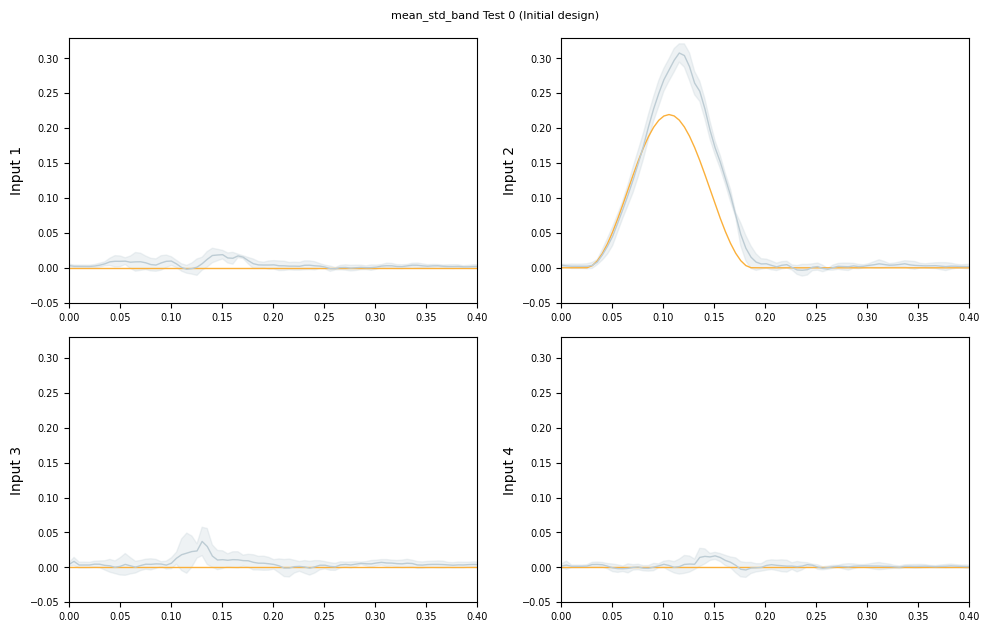

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


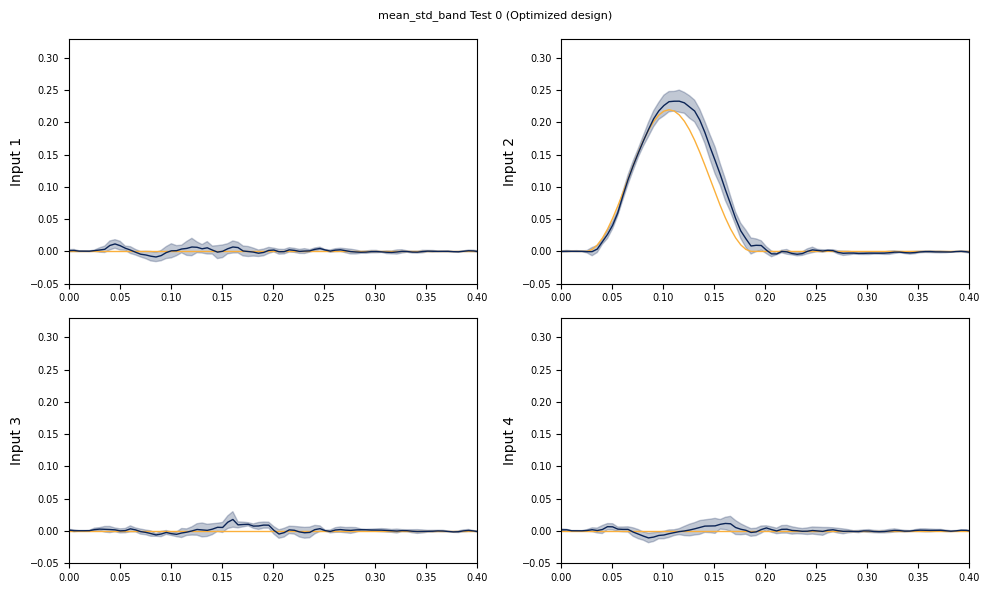

In [ ]:
configs = [
    ([(25,29)],            ["01062026"], 1),
    ([(24,41)],             ["01162026"], 1),
    ([(35,30)],             ["01162026"], 1),
    ([(13,30)],             ["01232026"], 1),
    ([(19,35)],             ["01232026"], 1), # 2 sensors
]

fname_list = []
idx_list = []

for idx_set, date_set, k in configs:
    for i, idx_tuple in enumerate(idx_set):
        date = date_set[i]
        idx_str = ",".join(str(x) for x in idx_tuple)
        file_idx = "_".join(str(x) for x in idx_tuple)
        fname = f"{date}_cooptimization_sim_1DCNN_data_300_n_source_4"
        if len(idx_tuple) > 0:
            fname += f"_measure_idx_{file_idx}_without_contact"
        fname += ".pickle"

    # mm_scaler = minmax_scaler(training_input_data, training_output_data)
    # show_results(fname, N=3, save_fig=True, name=file_idx+"_")
    fname_list.append(fname)
    idx_list.append(file_idx)

show_results_band(fname_list, N=1, save_fig=True, name="mean_std_band", idx_list=idx_list)

In [ ]:
configs = [
    ([(25,29)],            ["01062026"], 1),
    # ([(24,41)],             ["01162026"], 1),
    # ([(35,30)],             ["01162026"], 1),
    # ([(13,30)],             ["01232026"], 1),
    # ([(19,35)],             ["01232026"], 1), # 2 sensors
]

fname_list = []
idx_list = []
ts = jnp.linspace(0, 1.0, 200)
for idx_set, date_set, k in configs:
    for i, idx_tuple in enumerate(idx_set):
        date = date_set[i]
        idx_str = ",".join(str(x) for x in idx_tuple)
        file_idx = "_".join(str(x) for x in idx_tuple)
        fname = f"{date}_cooptimization_sim_1DCNN_data_300_n_source_4"
        if len(idx_tuple) > 0:
            fname += f"_measure_idx_{file_idx}_without_contact"
        fname += ".pickle"

    # mm_scaler = minmax_scaler(training_input_data, training_output_data)
    # show_results(fname, N=3, save_fig=True, name=file_idx+"_")
    fname_list.append(fname)
    idx_list.append(file_idx)

show_results_multi(fname_list, ts, N=30, save_fig=True, name="4_input_2_sensors_25_29_all_", idx_list=idx_list)

In [ ]:
configs = [
    # ([(57,)],              ["01062026"], 0),
    # ([(52,)],              ["01162026"], 0),
    # ([(53,)],              ["01172026"], 0),
    # ([(75,)],              ["01232026"], 0),
    # ([(80,)],              ["01232026"], 0), # 1 sensor
    # ([(52,62)],            ["01062026"], 1),
    # ([(75,62)],            ["01172026"], 1),
    # ([(75,85)],            ["01172026"], 1),
    # ([(77,83)],            ["01232026"], 1),
    # ([(60,77)],            ["01242026"], 1), # 2 sensors
    # ([(52,57,62)],         ["01062026"], 2),
    # ([(52,80,108)],        ["01172026"], 2),
    # ([(57,75,85)],         ["01172026"], 2),
    # ([(49,65,80)],         ["01242026"], 2),
    # ([(75,80,85)],         ["01242026"], 2), # 3 sensors
    # ([(49,55,60,65)],      ["01062026"], 3),
    # ([(72,78,83,88)],      ["01182026"], 3),
    ([(55,60,75,85)],      ["01182026"], 3),
    # ([(41,52,75,85)],      ["01242026"], 3),
    # ([(41,52,77,83)],      ["01242026"], 3), # 4 sensors
    # ([(49,53,57,61,65)],   ["01062026"], 4),
    # ([(72,76,80,84,88)],   ["01162026"], 4),
    # ([(49,57,65,76,84)],   ["01172026"], 4),
    # ([(53,61,74,86,103)],   ["01252026"], 4),
    # ([(53,57,61,74,86)],   ["01252026"], 4), # 5 sensors
    # ([(28,34,40,97,103,109)], ["01072026"], 5),
    # ([(49,56,63,97,104,111)], ["01172026"], 5),
    # ([(49,54,59,63,98,106)], ["01172026"], 5),
    # ([(51,55,59,63,79,84)], ["01242026"], 5),
    # ([(52,57,62,74,86,103)], ["01242026"], 5)# 6 sensors
]

fname_list = []
idx_list = []
ts = jnp.linspace(0, 1.0, 200)
for idx_set, date_set, k in configs:
    for i, idx_tuple in enumerate(idx_set):
        date = date_set[i]
        idx_str = ",".join(str(x) for x in idx_tuple)
        file_idx = "_".join(str(x) for x in idx_tuple)
        fname = f"{date}_cooptimization_sim_1DCNN_data_300_n_source_8"
        if len(idx_tuple) > 0:
            fname += f"_measure_idx_{file_idx}_without_contact"
        fname += ".pickle"

    fname_list.append(fname)
    idx_list.append(file_idx)

# show_results_band(fname_list, N=1, save_fig=True, name="mean_std_band",folder="8_input_source",  idx_list=idx_list, source_num=8)
# show_results(fname_list, N=2, save_fig=True, name="all_3_", folder="8_input_source", idx_list=idx_list, source_num=8)
show_results_multi(fname_list, ts, N=30, save_fig=True, folder="8_input_source",
                     name="8_input_4_sensors_"+file_idx+"_all_", idx_list=idx_list, source_num=8)

## 2 Input Source

In [10]:

n1_blocks = 5
n2_blocks = 4
n_source = 2
spacing = 15. + 0.075*15.  # 1.0  # 15 mm
hinge_length = 0.075*15.  # Same as bond length
initial_angle = -25.0*jnp.pi/180
horizontal_shifts, vertical_shifts = QuadGeometry_InputSource(n1_blocks, n2_blocks, spacing=spacing, bond_length=hinge_length, n_source=n_source).get_design_from_rotated_square(
    angle=initial_angle,
)  # Initial design

# Mechanical params
k_stretch = 4.00  # stretching stiffness 120. N/mm
k_shear = k_stretch * 2.1e-01 # shearing stiffness 1.19 N/mm
k_rot = k_stretch * 2.6902e-03 * 20.0 # rotational stiffness 1.50 Nmm

# NOTE: Damping is assumed to be the same for all blocks as it is small enough that the inertia change during optimization is negligible.
# The reference is taken to be zero angle rotated square geometry.
# 0.36125, 0.02175026 = mass and inertia of a single square of zero angle and unitary spacing and density and 0.15 bond length.

# Dynamic loading (default setting)
amplitude = jnp.ones((n1_blocks,)) * spacing  # 0.5 * spacing default 
loading_rate = 30.0 * jnp.ones((n1_blocks,))# jnp.array([30., 0., 20., 20., 20.])  #  Hz loading frequency for dynamic input
input_shift = 0
loaded_side = "top"
n_excited_blocks = n_source
input_delay = 0.1*30.0**-1 * jnp.ones((n1_blocks,))

min_angle=-15*jnp.pi/180
cutoff_angle=-10*jnp.pi/180

simulation_time = 1.0
n_timepoints = 200
ts = jnp.linspace(0, simulation_time, n_timepoints)
bond_length = hinge_length
linearized_strains = True # change from False to True for linearized strains
use_contact = True
k_contact = k_rot

geometry = QuadGeometry_InputSource(
    n1_blocks=n1_blocks,
    n2_blocks=n2_blocks,
    spacing=spacing,
    bond_length=bond_length,
    n_source=n_source
)

block_centroids, centroid_node_vectors, bond_connectivity, reference_bond_vectors = geometry.get_parametrization()
_bond_connectivity = bond_connectivity()  # Compute bond connectivity once as it is constant
_reference_bond_vectors = reference_bond_vectors(horizontal_shifts, vertical_shifts)  # Compute reference bond vectors once as they are constant

In [ ]:
def prediction_error(x_true, x_pred):
    error = jnp.sum((x_true-x_pred)**2)/jnp.sum(x_true**2)*100.0
    return error

# def prediction_error(x_true, x_pred):
#     # error = jnp.sqrt(jnp.sum((x_true-x_pred)**2)/jnp.sum(x_true**2))*100.0
#     error = jnp.linalg.norm( x_true-x_pred ) /jnp.linalg.norm( x_true ) * 100
#     return error

### Gaussian Impulse

data size :  (300, 200, 3)
data size :  (300, 200, 2)
(1, 1, 3) (1, 1, 3)
(1, 1, 2) (1, 1, 2)
data min :  [[[-4.30784639e+03 -4.36574389e+03 -3.47771941e+00]]]
data max :  [[[3.99710130e+03 2.24112443e+03 3.49992174e+00]]]
test data min :  [[[-0.79601671 -0.79664087]]]
test data max :  [[[0. 0.]]]
0.0983277201883298 -0.9410607322155404
training loss in original scale : 5.6377e-04
test loss in original scale : 7.3584e-04
1.0 0.0
training loss in original scale : 2.5097e-04
test loss in original scale : 2.8237e-04
TEST


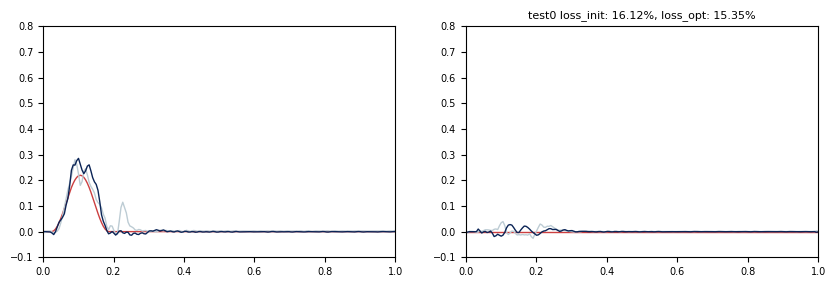

In [ ]:
# retrained model

hori_shifts_length = (n1_blocks+1) * n2_blocks * 2
with open("01152026_cooptimization_sim_1DCNN_data_300_n_source_2_without_contact.pickle", "rb") as f:
    record_dict = pickle.load(f)
param_record = record_dict["design_record"]
in_param_record = record_dict["nn_record"]
loss_record = record_dict["loss_record"]

min_idx = 95

# load simulation data
key = random.PRNGKey(0)
filename = "Simulation/input_source_2_training_dataset_measure_idx_7.pkl"
with open(filename, "rb") as f:
    results_dict = pickle.load(f)

input_data = results_dict['input_data']
output_data = results_dict['output_data']

test_N = input_data.shape[0] // 10 # 10 % of total data will be used as test data
test_idx = jax.random.randint(key, shape=(test_N,), minval=0, maxval=input_data.shape[0])

mask = jnp.ones(input_data.shape[0], dtype=bool).at[test_idx].set(False)

training_input_data = input_data[mask]
training_output_data = output_data[mask]

test_input_data = input_data[test_idx]
test_output_data = output_data[test_idx]

print("data size : ", input_data.shape)
print("data size : ", output_data.shape)

mm_scaler = minmax_scaler(training_input_data, training_output_data)
mm_scaler.information()

train_data_normalized, train_output_normalized = mm_scaler.transform(training_input_data, training_output_data)
test_data_normalized, test_output_normalized = mm_scaler.transform(test_input_data, test_output_data)
model = TimeSeriesCNN()

# initial parameters
params_init = in_param_record[0][0]
pred_y = model.apply(params_init, train_data_normalized)
pred_y_test = model.apply(params_init, test_data_normalized)

_, pred_y_org = mm_scaler.inverse_transform(train_data_normalized, pred_y)
_, pred_y_org_test = mm_scaler.inverse_transform(test_data_normalized, pred_y_test)
# _, train_output_org = mm_scaler.inverse_transform(train_data_normalized, train_output_normalized)
# _, test_output_org = mm_scaler.inverse_transform(test_data_normalized, test_output_normalized)

print( jnp.max(pred_y_org), jnp.min(pred_y_org) )

mse = jnp.mean((pred_y_org - training_output_data)**2)
mse_test = jnp.mean((pred_y_org_test - test_output_data)**2)
print(f"training loss in original scale : {mse:.4e}")
print(f"test loss in original scale : {mse_test:.4e}")

with open("01152026_cooptimization_sim_1DCNN_data_300_n_source_2_retrained_nn.pickle", "rb") as f:
    results_dict = pickle.load(f)

params_history = results_dict["params_history"]
params_opt = params_history[min_idx]

training_input_data = in_param_record[min_idx][2]
training_output_data = in_param_record[min_idx][3]
test_input_data = in_param_record[min_idx][4]
test_output_data = in_param_record[min_idx][5]

train_data_normalized, train_output_normalized = mm_scaler.transform(training_input_data, training_output_data)
test_data_normalized, test_output_normalized = mm_scaler.transform(test_input_data, test_output_data)
print( jnp.max(train_output_normalized), jnp.min(train_output_normalized) )

pred_y = model.apply(params_opt, train_data_normalized)
pred_y_test = model.apply(params_opt, test_data_normalized)

_, pred_y_org_opt = mm_scaler.inverse_transform(train_data_normalized, pred_y)
_, pred_y_org_test_opt = mm_scaler.inverse_transform(test_data_normalized, pred_y_test)

mse = jnp.mean((pred_y_org_opt - training_output_data)**2)
mse_test = jnp.mean((pred_y_org_test_opt - test_output_data)**2)
print(f"training loss in original scale : {mse:.4e}")
print(f"test loss in original scale : {mse_test:.4e}")

min_value = jnp.min(jnp.concatenate([training_output_data, test_output_data]))
color_list = ["#cc3f40", "#bdccd4", "#0b2456",]

print("TEST")
for i in range(1):
    plt.figure(figsize=(10,1.5*n_source))
    # min_value = jnp.min(jnp.concatenate([test_output_data[i,:,:], pred_y_org_test[i,:,:]])) * 1.3
    min_value = -0.8
    for j in range(n_source):
        plt.subplot(n_source//2,2,1+j)
        plt.plot( ts, -test_output_data[i,:,j], color=color_list[0], label="True")
        plt.plot( ts, -pred_y_org_test[i,:,j], color=color_list[1], label="Prediction from CNN")
        plt.plot( ts, -pred_y_org_test_opt[i,:,j], color=color_list[2], label="Prediction from CNN (optimized)")
        plt.ylim(-0.1, -min_value)
        plt.xlim(0,1.0)
        # plt.ylabel(f"Input {j+1}")
    # plt.tight_layout()
    # plt.suptitle(f"Test {i}")
    loss_init = jnp.sum((pred_y_org_test[i,:,:] - test_output_data[i,:,:])**2) / jnp.sum(test_output_data[i,:,:]**2) * 100.0
    loss_opt = jnp.sum((pred_y_org_test_opt[i,:,:] - test_output_data[i,:,:])**2) / jnp.sum(test_output_data[i,:,:]**2) * 100.0
    plt.title(f"test{i} loss_init: {loss_init:.2f}%, loss_opt: {loss_opt:.2f}%")
    # plt.savefig(f"Figure/gaussian_impulse_simulation/111925_sim_init_opt_design_prediction_test_data_{i}_time_no_ylimit.eps")
    # plt.savefig(f"Figure/gaussian_impulse_simulation/111925_sim_init_opt_design_prediction_test_data_{i}_time_no_ylimit.png")
    plt.show()

In [ ]:
test_output_data.shape

(30, 200, 2)

In [31]:

prediction_error_init = vmap(prediction_error, in_axes=(0, 0))(test_output_data, pred_y_org_test)
prediction_error_opt = vmap(prediction_error, in_axes=(0, 0))(test_output_data, pred_y_org_test_opt)

print("Initial mean prediction error :", jnp.mean(prediction_error_init))
print("Optimized mean prediction error :", jnp.mean(prediction_error_opt))

Initial mean prediction error : 37.68672422833775
Optimized mean prediction error : 24.308180490703023


In [24]:
def plot_performance_bars(names, values, colors, save_path, ylabel="Test MSE", horizontal=True):
    """Grouped bar chart for performance comparison."""
    fig, ax = plt.subplots(constrained_layout=True)
    x = jnp.arange(len(names))
    if horizontal:
        bars = ax.barh(x, values, color=colors)
        ax.set_yticks(x, names, fontsize=7)
        ax.invert_yaxis()
    else:
        bars = ax.bar(x, values, color=colors)
        ax.set_xticks(x, names, fontsize=7)
    ax.set_ylabel(ylabel)
    ax.set_xlim(0, max(values)*1.3)
    ax.bar_label(bars, fmt="%.2e", padding=3, fontsize=6)
    fig.savefig(save_path, dpi=300, bbox_inches="tight", pad_inches=0)
    plt.show()
    print(f"  Saved: {save_path}")

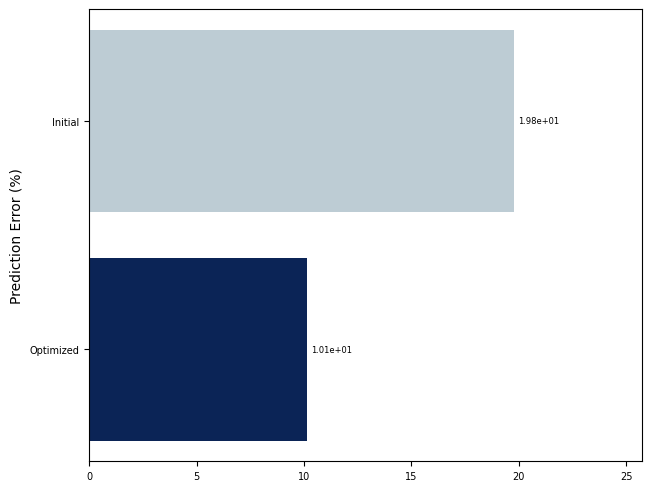

  Saved: Figure/gaussian_impulse_simulation/prediction_error_bars.png


In [33]:
# from collect_result_figures import plot_performance_bars
names = ["Initial", "Optimized"]
values = [jnp.mean(prediction_error_init), jnp.mean(prediction_error_opt)]
colors = ["#bdccd4", "#0b2456"]
save_path = "Figure/gaussian_impulse_simulation/prediction_error_bars.png"
plot_performance_bars(names, values, colors, save_path, ylabel="Prediction Error (%)")

## Broken Ligament Robustness

Test MSE uses original-scale MSE from the broken-ligament metric table. Mean prediction
error is the dataset average of per-sample relative squared prediction errors, not the
pooled relative error over the whole test set.


In [ ]:
import csv
import os

broken_metric_csv = "070326_broken_ligament_full_metrics_sim_data.csv"
broken_conditions = ["Pristine", "Zero-shot (broken)", "Fine-tuned (broken)"]
broken_condition_labels = ["Pristine", "Zero-shot\n(broken)", "Fine-tuned\n(broken)"]
broken_designs = ["Initial", "Optimized"]
broken_colors = {"Initial": "#bdccd4", "Optimized": "#0b2456"}

with open(broken_metric_csv, newline="") as f:
    broken_rows = list(csv.DictReader(f))

broken_metrics = {
    (row["design"], row["condition"]): {
        "test_mse_orig": float(row["test_mse_orig"]),
        "test_pred_err": float(row["test_pred_err"]),
    }
    for row in broken_rows
}


def plot_broken_ligament_grouped_metric(metric_key, ylabel, title, save_stem, value_fmt):
    x = list(range(len(broken_conditions)))
    width = 0.34
    fig, ax = plt.subplots(figsize=(6.4, 3.2), constrained_layout=True)

    all_values = []
    for offset, design in [(-width / 2, "Initial"), (width / 2, "Optimized")]:
        values = [broken_metrics[(design, condition)][metric_key] for condition in broken_conditions]
        all_values.extend(values)
        bars = ax.bar(
            [xi + offset for xi in x],
            values,
            width,
            label=f"{design} design",
            color=broken_colors[design],
            edgecolor="black",
            linewidth=0.4,
        )
        ax.bar_label(
            bars,
            labels=[value_fmt.format(value) for value in values],
            padding=2,
            fontsize=6,
        )

    ax.set_xticks(x)
    ax.set_xticklabels(broken_condition_labels)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.set_ylim(bottom=0)
    ax.set_ylim(top=max(all_values) * 1.25)
    ax.legend(frameon=False, fontsize=7)

    os.makedirs("Figure/gaussian_impulse_simulation", exist_ok=True)
    for ext in ["png", "eps"]:
        save_path = f"Figure/gaussian_impulse_simulation/{save_stem}.{ext}"
        fig.savefig(save_path, dpi=300, bbox_inches="tight", pad_inches=0.02)
        print(f"  Saved: {save_path}")
    plt.show()


print("Broken-ligament test metrics loaded from", broken_metric_csv)
for condition in broken_conditions:
    initial_mpe = broken_metrics[("Initial", condition)]["test_pred_err"]
    optimized_mpe = broken_metrics[("Optimized", condition)]["test_pred_err"]
    print(f"{condition:<20} mean prediction error: initial={initial_mpe:.2f}%  optimized={optimized_mpe:.2f}%")

plot_broken_ligament_grouped_metric(
    metric_key="test_mse_orig",
    ylabel="Test MSE (original scale)",
    title="Broken-ligament test MSE",
    save_stem="070326_broken_ligament_test_mse_original_scale",
    value_fmt="{:.2e}",
)

plot_broken_ligament_grouped_metric(
    metric_key="test_pred_err",
    ylabel="Test mean prediction error (%)",
    title="Broken-ligament mean prediction error",
    save_stem="070326_broken_ligament_test_mean_prediction_error",
    value_fmt="{:.2f}%",
)


# Sim, Exp result

data size :  (300, 200, 3)
data size :  (300, 200, 2)
(1, 1, 3) (1, 1, 3)
(1, 1, 2) (1, 1, 2)
data min :  [[[-9.20486815e+03 -6.06426438e+03 -3.11522804e+00]]]
data max :  [[[4.47803515e+03 8.62793362e+03 3.40469222e+00]]]
test data min :  [[[-0.85418995 -0.55896762]]]
test data max :  [[[-0. -0.]]]
training loss in original scale : 1.4347e-03
test loss in original scale : 1.5793e-03
1.0 0.0
training loss in original scale : 4.0090e-04
test loss in original scale : 2.9552e-04
TEST


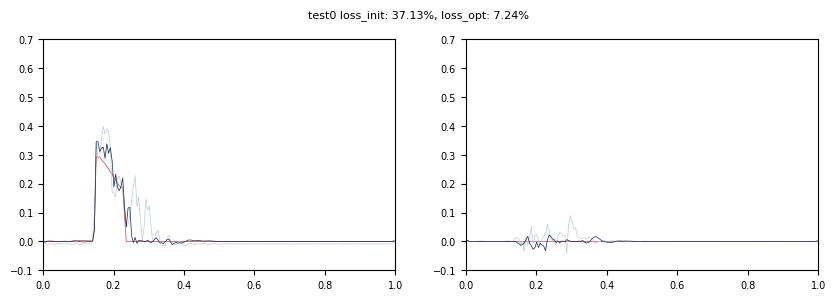

In [33]:
# results visualization
hori_shifts_length = (n1_blocks+1) * n2_blocks * 2
with open("11272025_cooptimization_real_1DCNN_data_300_n_source_2.pickle", "rb") as f:
    record_dict = pickle.load(f)
param_record = record_dict["design_record"]
in_param_record = record_dict["nn_record"]
loss_record = record_dict["loss_record"]

min_idx = jnp.argmin(jnp.array(loss_record))

# load simulation data
key = random.PRNGKey(0)
folder = "Experiments/Data/111925/"
with open(folder+"left_right_side_training_dataset.pkl", "rb") as f:
    results_dict = pickle.load(f)

input_data = results_dict['input_data']
output_data = results_dict['output_data']

test_N = input_data.shape[0] // 10 # 10 % of total data will be used as test data
test_idx = jax.random.randint(key, shape=(test_N,), minval=0, maxval=input_data.shape[0])

mask = jnp.ones(input_data.shape[0], dtype=bool).at[test_idx].set(False)
training_input_data = input_data[mask]
training_output_data = output_data[mask]
test_input_data = input_data[test_idx]
test_output_data = output_data[test_idx]

print("data size : ", input_data.shape)
print("data size : ", output_data.shape)

mm_scaler = minmax_scaler(training_input_data, training_output_data)
mm_scaler.information()

train_data_normalized, train_output_normalized = mm_scaler.transform(training_input_data, training_output_data)
test_data_normalized, test_output_normalized = mm_scaler.transform(test_input_data, test_output_data)
model = TimeSeriesCNN()

# initial design results
params_init = in_param_record[0][0]
pred_y = model.apply(params_init, train_data_normalized)
pred_y_test = model.apply(params_init, test_data_normalized)

_, pred_y_org = mm_scaler.inverse_transform(train_data_normalized, pred_y)
_, pred_y_org_test = mm_scaler.inverse_transform(test_data_normalized, pred_y_test)

mse = jnp.mean((pred_y_org - training_output_data)**2)
mse_test = jnp.mean((pred_y_org_test - test_output_data)**2)
print(f"training loss in original scale : {mse:.4e}")
print(f"test loss in original scale : {mse_test:.4e}")

params_opt = in_param_record[min_idx][0]
train_data_normalized = in_param_record[min_idx][2]
train_output_normalized = in_param_record[min_idx][3]
test_data_normalized = in_param_record[min_idx][4]
test_output_normalized = in_param_record[min_idx][5]

print( jnp.max(train_output_normalized), jnp.min(train_output_normalized) )

pred_y = model.apply(params_opt, train_data_normalized)
pred_y_test = model.apply(params_opt, test_data_normalized)

_, pred_y_org_opt = mm_scaler.inverse_transform(train_data_normalized, pred_y)
_, pred_y_org_test_opt = mm_scaler.inverse_transform(test_data_normalized, pred_y_test)

# print( jnp.max(pred_y_org), jnp.min(pred_y_org) )

mse = jnp.mean((pred_y_org_opt - training_output_data)**2)
mse_test = jnp.mean((pred_y_org_test_opt - test_output_data)**2)
print(f"training loss in original scale : {mse:.4e}")
print(f"test loss in original scale : {mse_test:.4e}")

color_list = ["#cc3f40", "#bdccd4", "#0b2456",]

print("TEST")
for i in range(1):
    plt.figure(figsize=(10,1.5*n_source))
    # min_value = jnp.min(jnp.concatenate([test_output_data[i,:,:], pred_y_org_test[i,:,:]])) * 1.3
    min_value = -0.7
    for j in range(n_source):
        plt.subplot(n_source//2,2,1+j)
        plt.plot( ts, -test_output_data[i,:,j], color=color_list[0], linewidth=0.5, label="True")
        plt.plot( ts, -pred_y_org_test[i,:,j], color=color_list[1], linewidth=0.5, label="Prediction from CNN")
        plt.plot( ts, -pred_y_org_test_opt[i,:,j], color=color_list[2], linewidth=0.5, label="Prediction from CNN (optimized)")
        plt.ylim(-0.1, -min_value)
    loss_init = jnp.sum((pred_y_org_test[i,:,:] - test_output_data[i,:,:])**2) / jnp.sum(test_output_data[i,:,:]**2) * 100.0
    loss_opt = jnp.sum((pred_y_org_test_opt[i,:,:] - test_output_data[i,:,:])**2) / jnp.sum(test_output_data[i,:,:]**2) * 100.0
    plt.suptitle(f"test{i} loss_init: {loss_init:.2f}%, loss_opt: {loss_opt:.2f}%")
    # plt.savefig(f"Figure/112925_simulation_data/111925_sim_init_opt_design_prediction_test_data_{i}_fixed_ylimit.eps")
    # plt.savefig(f"Figure/112925_simulation_data/111925_sim_init_opt_design_prediction_test_data_{i}_fixed_ylimit.png")
    plt.show()
    

In [34]:

prediction_error_init = vmap(prediction_error, in_axes=(0, 0))(test_output_data, pred_y_org_test)
prediction_error_opt = vmap(prediction_error, in_axes=(0, 0))(test_output_data, pred_y_org_test_opt)

print("Initial mean prediction error :", jnp.mean(prediction_error_init))
print("Optimized mean prediction error :", jnp.mean(prediction_error_opt))

Initial mean prediction error : 39.73066194179976
Optimized mean prediction error : 17.408283346149993


(1, 1, 3) (1, 1, 3)
(1, 1, 2) (1, 1, 2)
dict_keys(['train_loss_record', 'test_loss_record', 'params', 'train_data_normalized', 'train_output_normalized', 'test_data_normalized', 'test_output_normalized'])
mse :  0.005975047108054799
mse_test :  0.008029723368572323
check same data :  1.875134242508278e-20
check same data :  2.0001422474335583e-21
training loss in original scale : 3.2825e-03
test loss in original scale : 3.9371e-03
Initial mean prediction error : 66.17330030341243
TEST


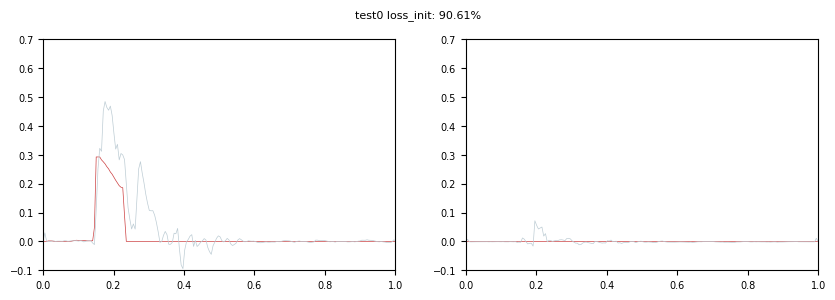

In [32]:
# experiment result

# load data of initial design
folder = "Experiments/Data/111925/"
with open(folder+"left_right_side_training_dataset.pkl", "rb") as f:
    results_dict = pickle.load(f)
    
input_data = results_dict['experiment_data']
output_data = results_dict['output_data']
key = random.PRNGKey(0)
test_N = input_data.shape[0] // 10 # 10 % of total data will be used as test data
test_idx = jax.random.randint(key, shape=(test_N,), minval=0, maxval=input_data.shape[0])
mask = jnp.ones(input_data.shape[0], dtype=bool).at[test_idx].set(False)

training_input_data = input_data[mask]
training_output_data = output_data[mask]

test_input_data = input_data[test_idx]
test_output_data = output_data[test_idx]
mm_scaler = minmax_scaler(training_input_data, training_output_data)

# initial design
with open("Figure/111925_exp_initial_design_train_nn.pickle", "rb") as f:
    results_dict = pickle.load(f)

print(results_dict.keys())

model = TimeSeriesCNN()
params = results_dict["params"]
train_data_normalized = results_dict["train_data_normalized"]
train_output_normalized = results_dict["train_output_normalized"]
test_data_normalized = results_dict["test_data_normalized"]
test_output_normalized = results_dict["test_output_normalized"]

pred_y = model.apply(params, train_data_normalized)
mse = jnp.mean((pred_y - train_output_normalized)**2)
print("mse : ", mse)
pred_y_test = model.apply(params, test_data_normalized)
mse_test = jnp.mean((pred_y_test - test_output_normalized)**2)
print("mse_test : ", mse_test)

training_input_data_temp, pred_y_org = mm_scaler.inverse_transform(train_data_normalized, pred_y)
test_input_data_temp, pred_y_org_test = mm_scaler.inverse_transform(test_data_normalized, pred_y_test)
print( "check same data : ", jnp.sum( (training_input_data_temp - training_input_data)**2 ) )
print( "check same data : ", jnp.sum( (test_input_data_temp - test_input_data)**2 ) )

mse = jnp.mean((pred_y_org - training_output_data)**2)
mse_test = jnp.mean((pred_y_org_test - test_output_data)**2)
print(f"training loss in original scale : {mse:.4e}")
print(f"test loss in original scale : {mse_test:.4e}")

prediction_error_init = vmap(prediction_error, in_axes=(0, 0))(test_output_data, pred_y_org_test)
print("Initial mean prediction error :", jnp.mean(prediction_error_init))

color_list = ["#cc3f40", "#bdccd4", "#0b2456",]

print("TEST")
for i in range(1):
    plt.figure(figsize=(10,1.5*n_source))
    # min_value = jnp.min(jnp.concatenate([test_output_data[i,:,:], pred_y_org_test[i,:,:]])) * 1.3
    min_value = -0.7
    for j in range(n_source):
        plt.subplot(n_source//2,2,1+j)
        plt.plot( ts, -test_output_data[i,:,j], color=color_list[0], linewidth=0.5, label="True")
        plt.plot( ts, -pred_y_org_test[i,:,j], color=color_list[1], linewidth=0.5, label="Prediction from CNN")
        # plt.plot( ts, -pred_y_org_test_opt[i,:,j], color=color_list[2], linewidth=0.5, label="Prediction from CNN (optimized)")
        plt.ylim(-0.1, -min_value)
    loss_init = jnp.sum((pred_y_org_test[i,:,:] - test_output_data[i,:,:])**2) / jnp.sum(test_output_data[i,:,:]**2) * 100.0
    # plt.suptitle(f"test{i} loss_init: {loss_init:.2f}%, loss_opt: {loss_opt:.2f}%")
    plt.suptitle(f"test{i} loss_init: {loss_init:.2f}%")
    # plt.savefig(f"Figure/111925_experiment_data/111925_exp_init_design_prediction_test_data_{i}_fixed_ylimit.eps")
    # plt.savefig(f"Figure/111925_experiment_data/111925_exp_init_design_prediction_test_data_{i}_fixed_ylimit.png")
    plt.show()

(1, 1, 3) (1, 1, 3)
(1, 1, 2) (1, 1, 2)
dict_keys(['train_loss_record', 'test_loss_record', 'params', 'train_data_normalized', 'train_output_normalized', 'test_data_normalized', 'test_output_normalized'])
mse :  0.004323321619810756
mse_test :  0.004978128690937171
check same data :  2.059561877156571e-20
check same data :  2.2920184141903574e-21
training loss in original scale : 1.6536e-03
test loss in original scale : 1.8949e-03
Optimized mean prediction error : 53.853598364556795
Optimized mean prediction error : 52.75800735699083
TEST
debug :  28.754848730844447


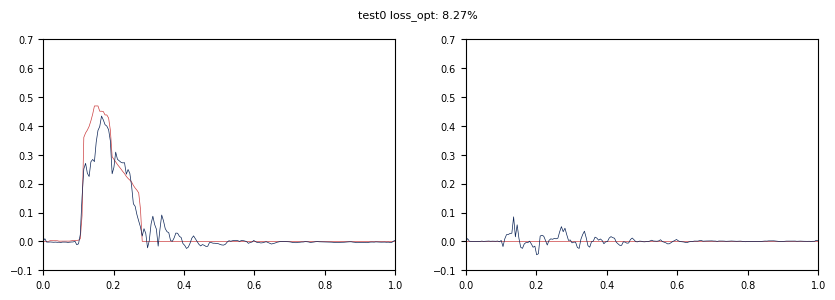

In [40]:

# ===============================================
folder = "Experiments/Data/120225/"
with open(folder+"left_right_side_training_dataset.pkl", "rb") as f:
    results_dict = pickle.load(f)
    
input_data = results_dict['experiment_data']
output_data = results_dict['output_data']
key = random.PRNGKey(0)
test_N = input_data.shape[0] // 10 # 10 % of total data will be used as test data
test_idx = jax.random.randint(key, shape=(test_N,), minval=0, maxval=input_data.shape[0])
mask = jnp.ones(input_data.shape[0], dtype=bool).at[test_idx].set(False)

training_input_data = input_data[mask]
training_output_data = output_data[mask]

test_input_data = input_data[test_idx]
test_output_data = output_data[test_idx]
# SET MINMAX SCALER
mm_scaler = minmax_scaler(training_input_data, training_output_data)

# optimized design
with open("Figure/111925_exp_opt_design_train_nn.pickle", "rb") as f:
    results_dict = pickle.load(f)

print(results_dict.keys())

model = TimeSeriesCNN()
params = results_dict["params"]
train_data_normalized = results_dict["train_data_normalized"]
train_output_normalized = results_dict["train_output_normalized"]
test_data_normalized = results_dict["test_data_normalized"]
test_output_normalized = results_dict["test_output_normalized"]

pred_y = model.apply(params, train_data_normalized)
mse = jnp.mean((pred_y - train_output_normalized)**2)
print("mse : ", mse)
pred_y_test = model.apply(params, test_data_normalized)
mse_test = jnp.mean((pred_y_test - test_output_normalized)**2)
print("mse_test : ", mse_test)

training_input_data_temp, pred_y_org_opt = mm_scaler.inverse_transform(train_data_normalized, pred_y)
test_input_data_temp, pred_y_org_test_opt = mm_scaler.inverse_transform(test_data_normalized, pred_y_test)
print( "check same data : ", jnp.sum( (training_input_data_temp - training_input_data)**2 ) )
print( "check same data : ", jnp.sum( (test_input_data_temp - test_input_data)**2 ) )

mse = jnp.mean((pred_y_org_opt - training_output_data)**2)
mse_test = jnp.mean((pred_y_org_test_opt - test_output_data)**2)
print(f"training loss in original scale : {mse:.4e}")
print(f"test loss in original scale : {mse_test:.4e}")

prediction_error_opt = vmap(prediction_error, in_axes=(0, 0))(test_output_data, pred_y_org_test_opt)
prediction_error_opt_train = vmap(prediction_error, in_axes=(0, 0))(training_output_data, pred_y_org_opt)
print("Optimized mean prediction error :", jnp.mean(prediction_error_opt))
print("Optimized mean prediction error :", jnp.mean(jnp.concatenate((prediction_error_opt,prediction_error_opt_train))))

color_list = ["#cc3f40", "#bdccd4", "#0b2456",]

print("TEST")
for i in range(1):
    plt.figure(figsize=(10,1.5*n_source))
    # min_value = jnp.min(jnp.concatenate([test_output_data[i,:,:], pred_y_org_test[i,:,:]])) * 1.3
    min_value = -0.7
    for j in range(n_source):
        plt.subplot(n_source//2,2,1+j)
        plt.plot( ts, -test_output_data[i,:,j], color=color_list[0], linewidth=0.5, label="True")
        # plt.plot( ts, -pred_y_org_test[i,:,j], color=color_list[1], linewidth=0.5, label="Prediction from CNN")
        plt.plot( ts, -pred_y_org_test_opt[i,:,j], color=color_list[2], linewidth=0.5, label="Prediction from CNN (optimized)")
        plt.ylim(-0.1, -min_value)
    print( "debug : ", prediction_error(test_output_data[i], pred_y_org_test_opt[i]) )
    loss_opt = jnp.sum((pred_y_org_test_opt[i,:,:] - test_output_data[i,:,:])**2) / jnp.sum(test_output_data[i,:,:]**2) * 100.0
    # plt.suptitle(f"test{i} loss_init: {loss_init:.2f}%, loss_opt: {loss_opt:.2f}%")
    plt.suptitle(f"test{i} loss_opt: {loss_opt:.2f}%")
    # plt.savefig(f"Figure/111925_experiment_data/111925_exp_opt_design_prediction_test_data_{i}_fixed_ylimit.eps")
    # plt.savefig(f"Figure/111925_experiment_data/111925_exp_opt_design_prediction_test_data_{i}_fixed_ylimit.png")
    plt.show()

In [18]:
prediction_error_opt = vmap(prediction_error, in_axes=(0, 0))(test_output_data, pred_y_org_test_opt)
print("Optimized mean prediction error :", jnp.mean(prediction_error_opt))

Optimized mean prediction error : 30.604511886647103


In [36]:
jnp.median(prediction_error_opt), jnp.median(prediction_error_init)

(Array(54.6715559, dtype=float64), Array(36.66433972, dtype=float64))

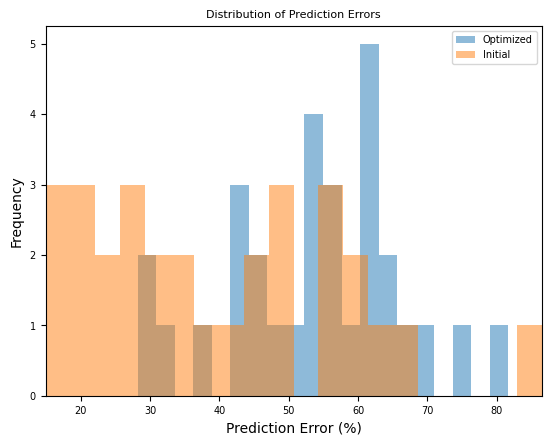

In [37]:
plt.hist(prediction_error_opt, bins=20, label="Optimized", alpha=0.5)
plt.hist(prediction_error_init, bins=20, label="Initial", alpha=0.5)
plt.legend()
plt.xlabel("Prediction Error (%)")
plt.ylabel("Frequency")
plt.title("Distribution of Prediction Errors")
# plt.savefig("Figure/gaussian_impulse_simulation/prediction_error_histogram.png")
plt.show()

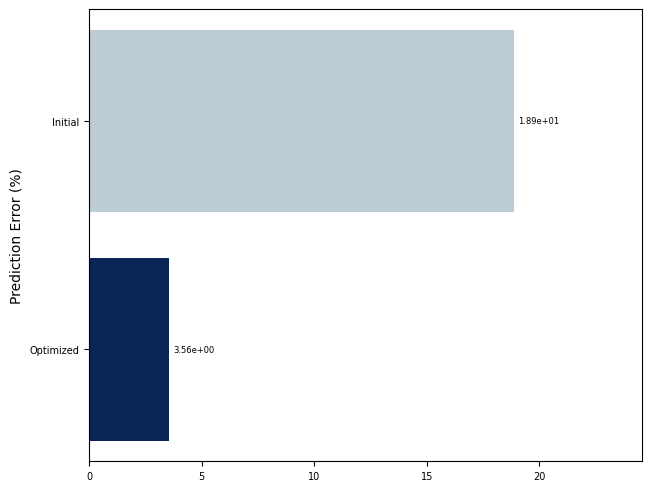

  Saved: Figure/prediction_error_bars_only_simulation_given_init_force_data.eps


In [25]:
# from collect_result_figures import plot_performance_bars
names = ["Initial", "Optimized"]
values = [18.88437717207064, 3.5554800872611083]
colors = ["#bdccd4", "#0b2456"]
save_path = "Figure/prediction_error_bars_only_simulation_given_init_force_data.eps"
plot_performance_bars(names, values, colors, save_path, ylabel="Prediction Error (%)")

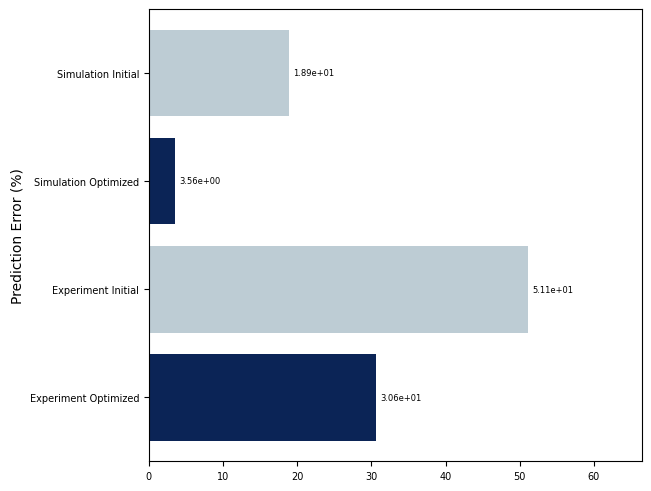

  Saved: Figure/112925_simulation_data/prediction_error_bars_simulation_experiment.eps


In [21]:
# bar plot
names = ["Simulation Initial", "Simulation Optimized", "Experiment Initial", "Experiment Optimized"]
values = [18.88437717207064, 3.5554800872611083, 51.09791765472119, 30.604511886647103]
colors = ["#bdccd4", "#0b2456","#bdccd4", "#0b2456"]
save_path = "Figure/112925_simulation_data/prediction_error_bars_simulation_experiment.eps"
plot_performance_bars(names, values, colors, save_path, ylabel="Prediction Error (%)")

## Multiple sensors

In [30]:
def prediction_error(x_true, x_pred):
    error = jnp.sum((x_true-x_pred)**2)/jnp.sum(x_true**2)*100.0
    return error

def show_results_band(fname_list, N=4, save_fig=False, folder="4_input_source",
                        name="", idx_list=None, source_num=4,
                        color_list=["#cc3f40", "#bdccd4", "#0b2456"], show_off=False, min_value=-0.8):
    if idx_list is None:
        idx_list = [f"File {k}" for k in range(len(fname_list))]


    # Collect predictions from all files
    list_pred_init = []
    list_pred_opt = []
    test_output_i = None
    n_source = None

    for k in range(len(fname_list)):
        
        filename = f"Simulation/input_source_{source_num}_training_dataset_measure_idx_{idx_list[k]}.pickle"
        print("Checking for data file at:", filename)
        with open(filename, "rb") as f:
            record_dict = pickle.load(f)
        
        mm_scaler = minmax_scaler(record_dict["input_data"], record_dict["output_data"])

        fname = fname_list[k]
        print("cooptimization data file : ", fname)
        with open(fname, "rb") as f:
            record_dict = pickle.load(f)

        train_data, train_output, test_data, test_output = record_dict["initial_data"]
        params = record_dict["nn_record"][0][0]
        model = TimeSeriesCNN(output_features=train_output.shape[-1])

        train_data_normalized, train_output_normalized = mm_scaler.transform(train_data, train_output)
        test_data_normalized, test_output_normalized = mm_scaler.transform(test_data, test_output)
        pred_y_test = model.apply(params, test_data_normalized)
        _, pred_y_test_org = mm_scaler.inverse_transform(test_data, pred_y_test)

        train_data, train_output, test_data, test_output = record_dict["optimal_data"]
        opt_idx = jnp.argmin(jnp.array(record_dict["loss_record"]))
        opt_params = record_dict["nn_record"][opt_idx][0]
        train_data_normalized, train_output_normalized = mm_scaler.transform(train_data, train_output)
        test_data_normalized, test_output_normalized = mm_scaler.transform(test_data, test_output)
        pred_y_test_opt = model.apply(opt_params, test_data_normalized)
        _, pred_y_test_opt_org = mm_scaler.inverse_transform(test_data, pred_y_test_opt)

        list_pred_init.append(pred_y_test_org)
        list_pred_opt.append(pred_y_test_opt_org)
        if k == 0:
            test_output_i = test_output
        else:
            print( "check data are same : ", jnp.sum(jnp.abs(test_output_i - test_output)) )
        n_source = train_output.shape[-1]

    pred_init_array = jnp.stack(list_pred_init, axis=0) # (number of file, N, Timesteps, n_source)
    pred_opt_array = jnp.stack(list_pred_opt, axis=0) # (number of file, N, Timesteps, n_source)

    # diff = pred_opt_array - test_output_i[None, :, :, :] # (number of file, N, Timesteps, n_source)
    print("pred_opt_array shape : ", pred_opt_array.shape)
    print("test_output_i shape : ", test_output_i.shape)
    pred_error =jnp.zeros((pred_opt_array.shape[0], test_output_i.shape[0])) # (number of file, N)
    for i in range(pred_opt_array.shape[0]):
        pred_error_temp = vmap(prediction_error, in_axes=(0,0))(pred_opt_array[i], test_output_i) # (N,)
        pred_error = pred_error.at[i].set(pred_error_temp)
    mean_prediction_error = jnp.mean(pred_error, axis=0) # (N,)
    mean_pred_init = jnp.mean(pred_init_array, axis=0) # (N, Timesteps, n_source)
    std_pred_init = jnp.std(pred_init_array, axis=0) # (N, Timesteps, n_source)
    mean_pred_opt = jnp.mean(pred_opt_array, axis=0) # (N, Timesteps, n_source)
    std_pred_opt = jnp.std(pred_opt_array, axis=0) # (N, Timesteps, n_source)

    # Figure 2: Optimized design – mean prediction with std band
    all_errors = []
    for i in range(N):
        plt.figure(figsize=(10, 1.5 * n_source))
        
        for j in range(n_source):
            plt.subplot(n_source // 2, 2, 1 + j)
            true_signal = -test_output_i[i, :, j]
            mean_signal = -mean_pred_opt[i, :, j]
            std_signal = std_pred_opt[i, :, j]


            plt.plot(ts, true_signal, "-", color=color_list[0], label="True")
            plt.plot(ts, mean_signal, "-", color=color_list[2], label="Mean prediction (optimized)")
            plt.fill_between(
                ts,
                mean_signal - std_signal,
                mean_signal + std_signal,
                color=color_list[2],
                alpha=0.25,
                label="Std dev",
            )
            # plt.xlim(0, 0.4)
            plt.ylim(-5e-2, -min_value)
            plt.ylabel(f"Input {j+1}")
        
        plt.suptitle(f"{name} Test {i} (Optimized design) | Mean Error: {mean_prediction_error[i]:.2f}%")
        # plt.legend()
        plt.tight_layout()
        if save_fig:
            plt.savefig(f"Figure/{folder}/{name}Test_{i}_opt_band.eps", bbox_inches="tight")
            plt.savefig(f"Figure/{folder}/{name}Test_{i}_opt_band.png", bbox_inches="tight")
            print(f"  Saved: Figure/{folder}/{name}Test_{i}_opt_band.png")
        if show_off==False:
            plt.show()
        else:
            plt.close()

    overall_mean_error = float(jnp.mean(jnp.array(all_errors)))
    print(f"Overall mean prediction error across {N} test cases: {overall_mean_error:.2f}%")
    return all_errors


In [59]:

def load_and_plot(path, color, label):
    with open(path, "rb") as f:
        record = pickle.load(f)
    loss = jnp.array(record["loss_record"])

    min_idx = jnp.argmin( loss )
    nn_record = record["nn_record"]
    init_data = nn_record[0][2:6]
    opt_data = nn_record[min_idx][2:6]
    in_param_record = []

    for i in range(100):
        in_param_record.append( nn_record[i][0:2] )
        
    record_dict_2 = {"outer_iter": record["outer_iter"],
                    "inner_iter": record["inner_iter"],
                    "outer_lr": record["outer_lr"],
                    "inner_lr": record["inner_lr"],
                    "design_record": record["design_record"],
                    "nn_record": in_param_record,
                    "loss_record": record["loss_record"],
                    "initial_data": init_data,
                    "optimal_data": opt_data}
                    
    with open(path, "wb") as f:
        pickle.dump(record_dict_2, f)

    return loss[0], loss.min()

load_and_plot("03042026_cooptimization_sim_1DCNN_data_300_n_source_8_measure_idx_49_60_100_111_without_contact.pickle", color_list[0], "01062026")

(Array(0.00054633, dtype=float64), Array(0.00022209, dtype=float64))

In [55]:
with open("01162026_cooptimization_sim_1DCNN_data_300_n_source_4_measure_idx_25_29_38_without_contact.pickle", "rb") as f:
    record_dict = pickle.load(f)
param_record = record_dict["design_record"]
in_param_record = record_dict["nn_record"]
loss_record = record_dict["loss_record"]

print(record_dict.keys())

dict_keys(['outer_iter', 'inner_iter', 'outer_lr', 'inner_lr', 'design_record', 'nn_record', 'loss_record'])


In [ ]:
with open("01192026_cooptimization_sim_1DCNN_data_300_n_source_8_measure_idx_62_without_contact.pickle", "rb") as f:
    record_dict = pickle.load(f)
param_record = record_dict["design_record"]
in_param_record = record_dict["nn_record"]
loss_record = record_dict["loss_record"]

print(record_dict.keys())
print( record_dict["initial_data"] )
# plt.plot(jnp.arange(len(loss_record)), jnp.array(loss_record), color=color_list[0], lw=3)
# plt.title('Cooptimization : design training curve')
# plt.yscale('log')
# plt.ylabel("Outer loss")
# plt.xlabel("Iterations")
# # plt.legend()
# plt.show()


In [ ]:
configs_set = [
    [([(57,)],              ["01062026"], 0),
    ([(62,)],              ["01192026"], 0),
    ([(53,)],              ["01172026"], 0),
    ([(75,)],              ["01232026"], 0),
    ([(80,)],              ["01232026"], 0)], # 1 sensor
    [([(52,62)],            ["01062026"], 1),
    ([(75,62)],            ["01172026"], 1),
    ([(75,85)],            ["01172026"], 1),
    ([(77,83)],            ["01232026"], 1),
    ([(60,77)],            ["01242026"], 1)], # 2 sensors
    [([(52,57,62)],         ["01062026"], 2),
    ([(52,80,108)],         ["01172026"], 2),
    ([(57,75,85)],         ["01172026"], 2),
    ([(49,65,80)],         ["01242026"], 2),
    ([(75,80,85)],         ["01242026"], 2)], # 3 sensors
    [([(49,55,60,65)],      ["01062026"], 3),
    ([(55,60,75,85)],      ["01182026"], 3),
    ([(41,52,75,85)],      ["01242026"], 3),
    ([(41,52,77,83)],      ["01242026"], 3),
    ([(49,60,100,111)],     ["03042026"], 3)], # 4 sensors
    [([(49,53,57,61,65)],   ["01062026"], 4),
    ([(72,76,80,84,88)],   ["01162026"], 4),
    ([(49,57,65,76,84)],   ["01172026"], 4),
    ([(53,61,74,86,103)],   ["01252026"], 4),
    ([(53,57,61,74,86)],   ["01252026"], 4)], # 5 sensors
    [([(28,34,40,97,103,109)], ["01072026"], 5),
    ([(49,56,63,97,104,111)], ["01172026"], 5),
    ([(49,54,59,63,98,106)], ["01172026"], 5),
    ([(51,55,59,63,79,84)], ["01242026"], 5),
    ([(52,57,62,74,86,103)], ["01242026"], 5) ] # 6 sensors
]
color_list = ["#d26766", "#6bb150", "#e4c55f", "#a74f94", "#c6c72e","#f69a47"]
name_list = ["1 sensor_", "2 sensors_", "3 sensors_", "4 sensors_", "5 sensors_", "6 sensors_"]
for m in range(len(configs_set)):
    configs = configs_set[m]
    fname_list = []
    idx_list = []
    
    for idx_set, date_set, k in configs:
        for i, idx_tuple in enumerate(idx_set):
            date = date_set[i]
            idx_str = ",".join(str(x) for x in idx_tuple)
            file_idx = "_".join(str(x) for x in idx_tuple)
            fname = f"{date}_cooptimization_sim_1DCNN_data_300_n_source_8"
            if len(idx_tuple) > 0:
                fname += f"_measure_idx_{file_idx}_without_contact"
            fname += ".pickle"
        color_list_for_band = ["k", "#bdccd4", color_list[k]]

        # mm_scaler = minmax_scaler(training_input_data, training_output_data)
        # show_results(fname, N=3, save_fig=True, name=file_idx+"_")
        fname_list.append(fname)
        idx_list.append(file_idx)

    show_results_band(fname_list, N=30, save_fig=True, name=name_list[m],
        folder="8_input_source", idx_list=idx_list, source_num=8, color_list=color_list_for_band,
        show_off=True, min_value=-0.6)

Checking for data file at: Simulation/input_source_4_training_dataset_measure_idx_38.pickle
(1, 1, 3) (1, 1, 3)
(1, 1, 4) (1, 1, 4)
cooptimization data file :  01062026_cooptimization_sim_1DCNN_data_300_n_source_4_measure_idx_38_without_contact.pickle
Checking for data file at: Simulation/input_source_4_training_dataset_measure_idx_27.pickle
(1, 1, 3) (1, 1, 3)
(1, 1, 4) (1, 1, 4)
cooptimization data file :  01142026_cooptimization_sim_1DCNN_data_300_n_source_4_measure_idx_27_without_contact.pickle
check data are same :  0.0
Checking for data file at: Simulation/input_source_4_training_dataset_measure_idx_49.pickle
(1, 1, 3) (1, 1, 3)
(1, 1, 4) (1, 1, 4)
cooptimization data file :  01142026_cooptimization_sim_1DCNN_data_300_n_source_4_measure_idx_49_without_contact.pickle
check data are same :  0.0
Checking for data file at: Simulation/input_source_4_training_dataset_measure_idx_24.pickle
(1, 1, 3) (1, 1, 3)
(1, 1, 4) (1, 1, 4)
cooptimization data file :  01232026_cooptimization_sim_1D

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


  Saved: Figure/4_input_source/1 sensor_Test_0_opt_band.png


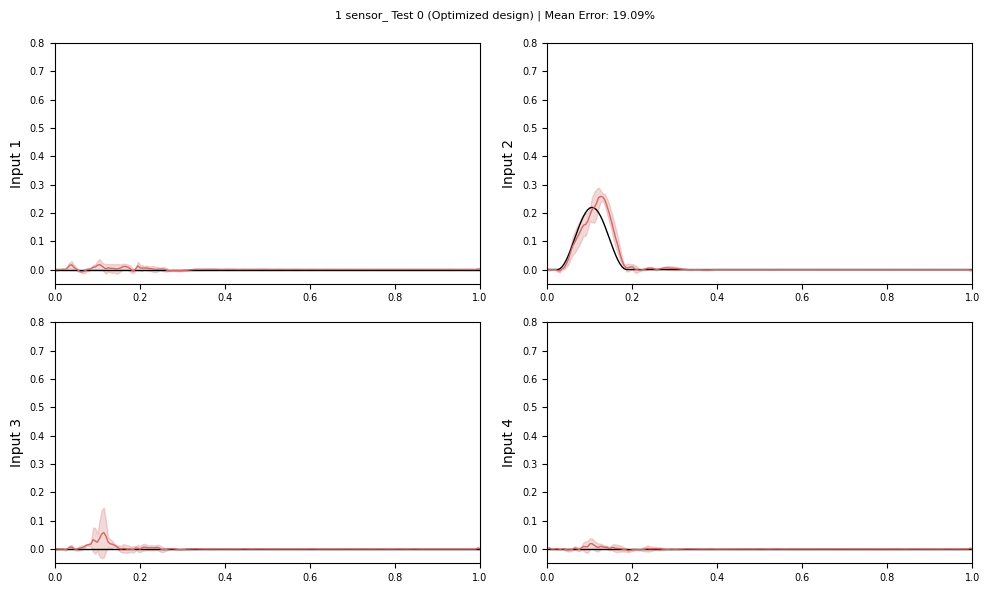

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


  Saved: Figure/4_input_source/1 sensor_Test_1_opt_band.png


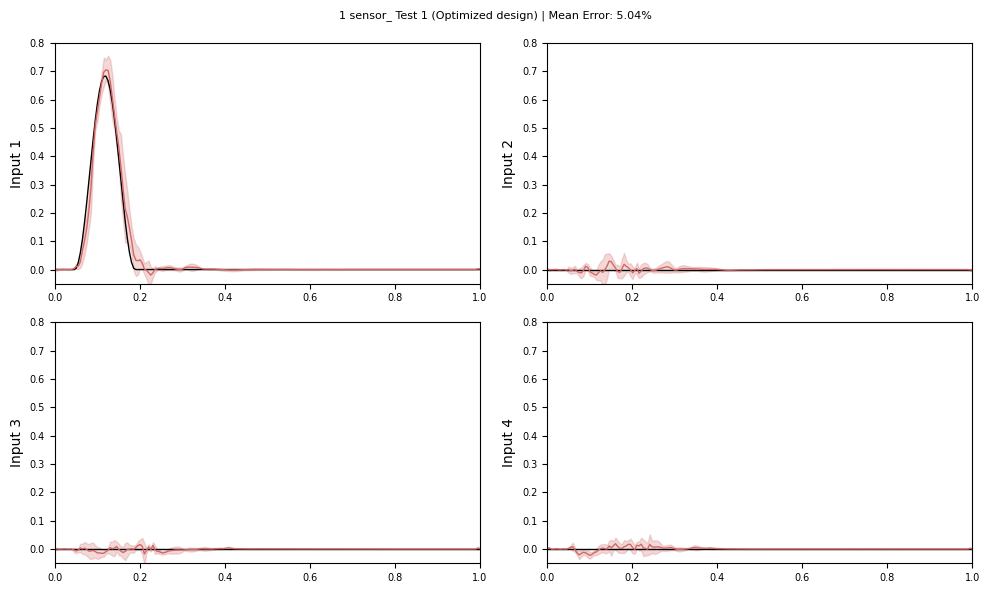

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


  Saved: Figure/4_input_source/1 sensor_Test_2_opt_band.png


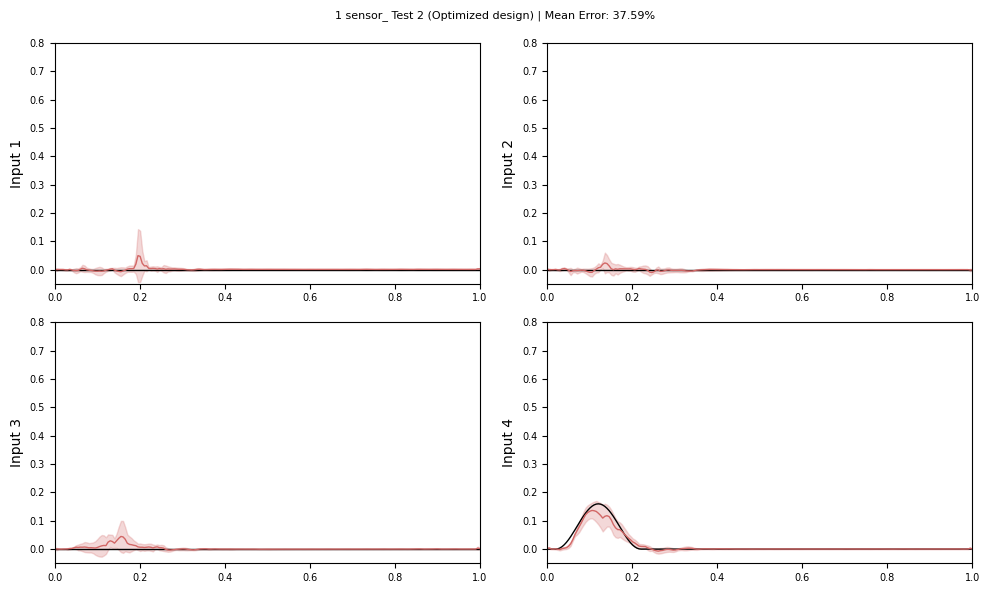

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


  Saved: Figure/4_input_source/1 sensor_Test_3_opt_band.png


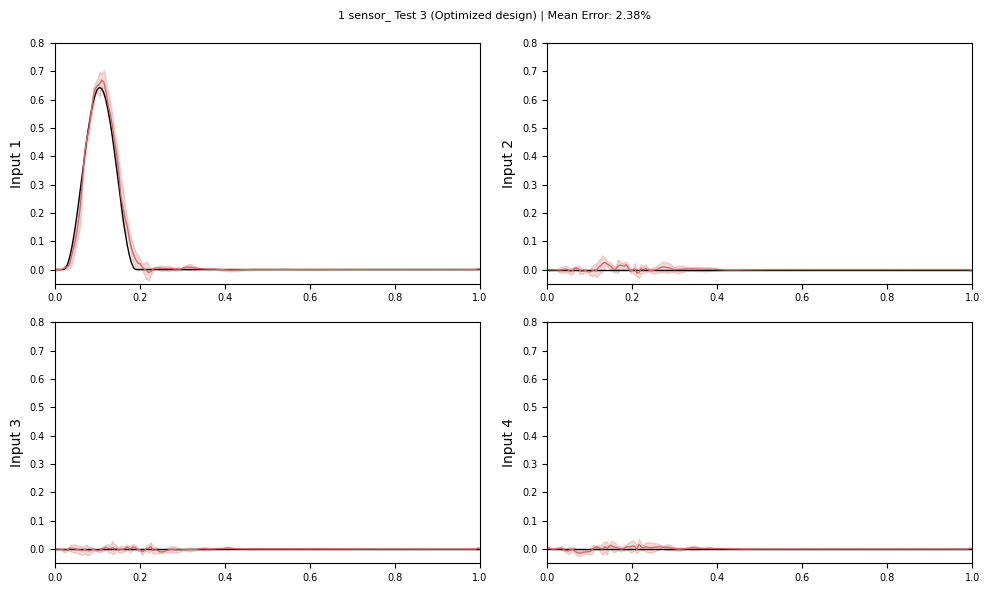

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


  Saved: Figure/4_input_source/1 sensor_Test_4_opt_band.png


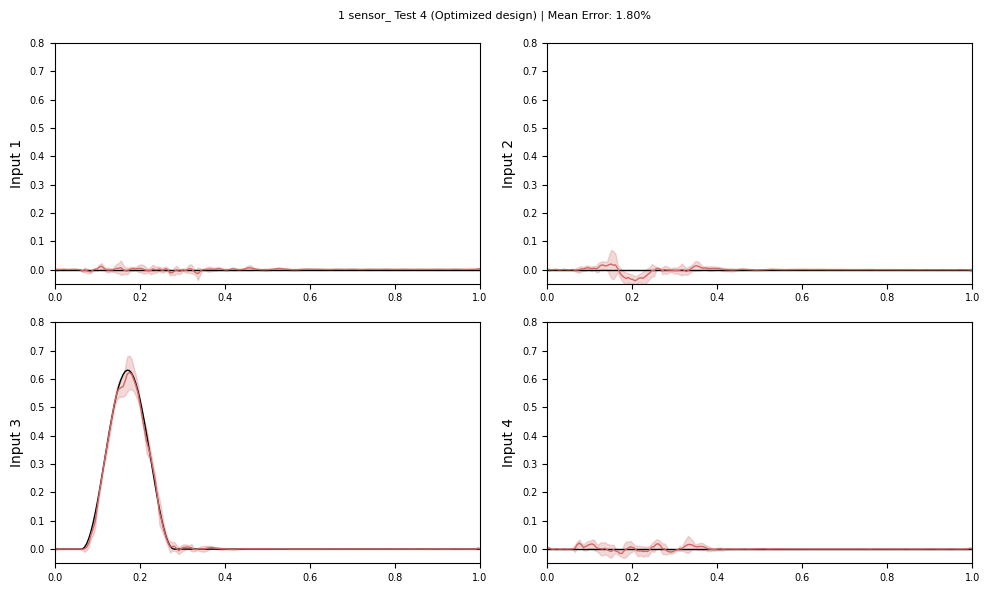

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


  Saved: Figure/4_input_source/1 sensor_Test_5_opt_band.png


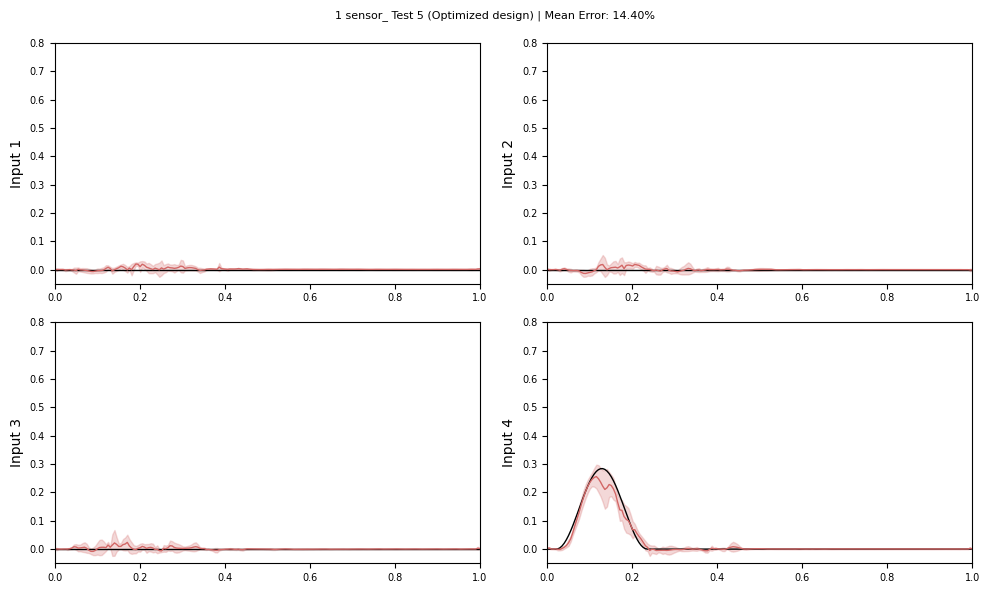

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


  Saved: Figure/4_input_source/1 sensor_Test_6_opt_band.png


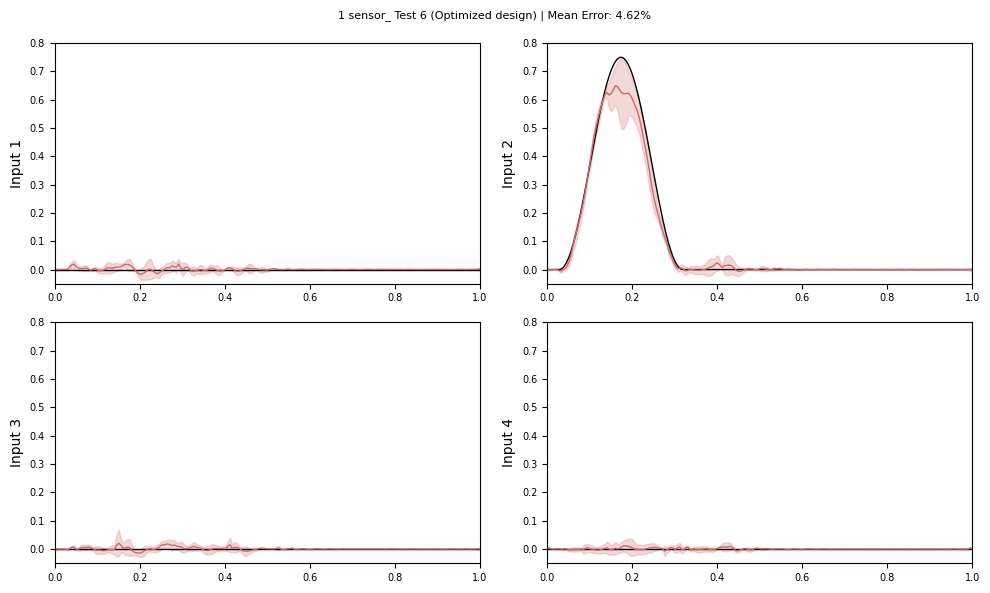

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


  Saved: Figure/4_input_source/1 sensor_Test_7_opt_band.png


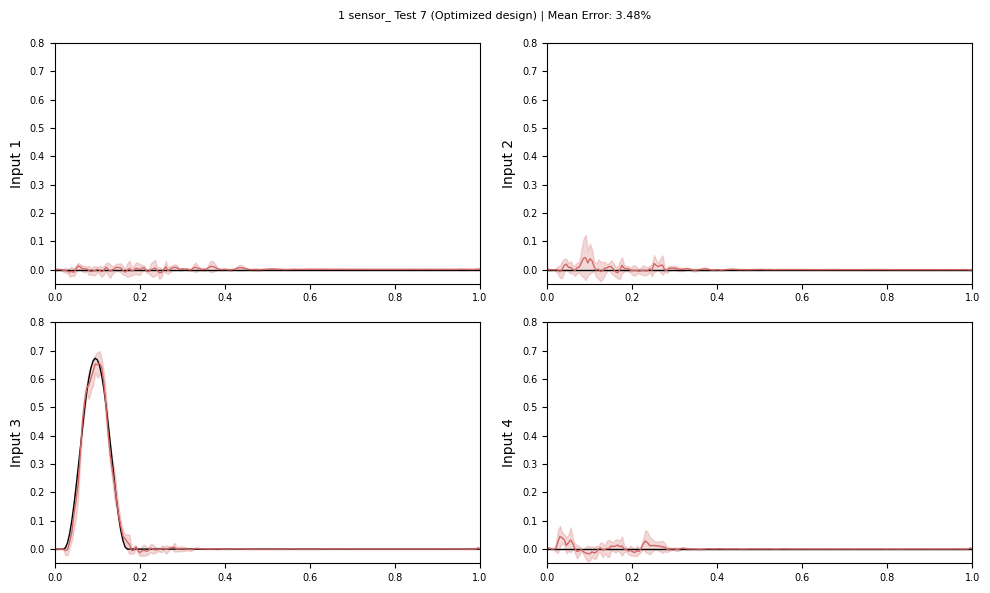

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


  Saved: Figure/4_input_source/1 sensor_Test_8_opt_band.png


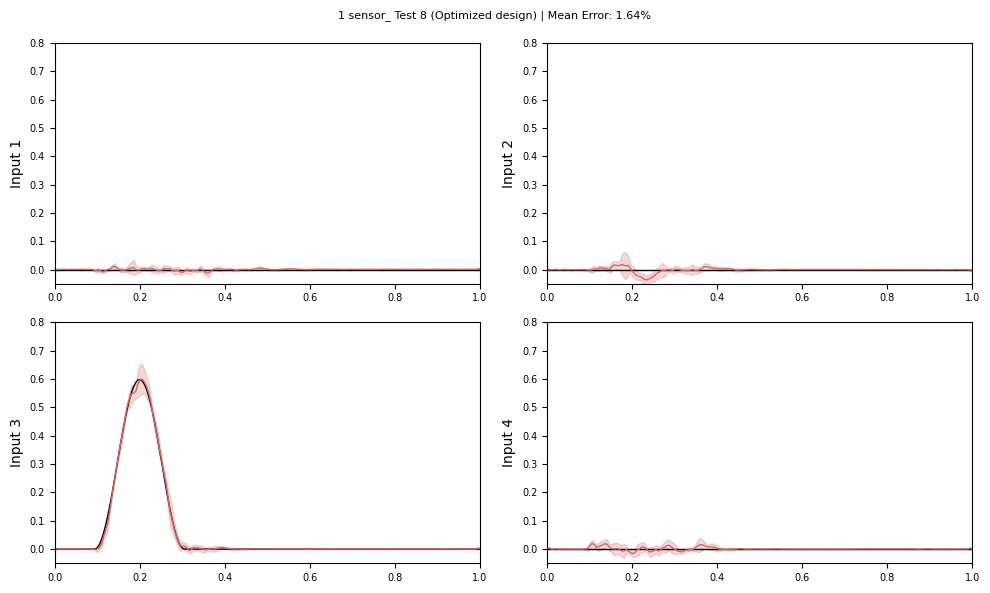

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


  Saved: Figure/4_input_source/1 sensor_Test_9_opt_band.png


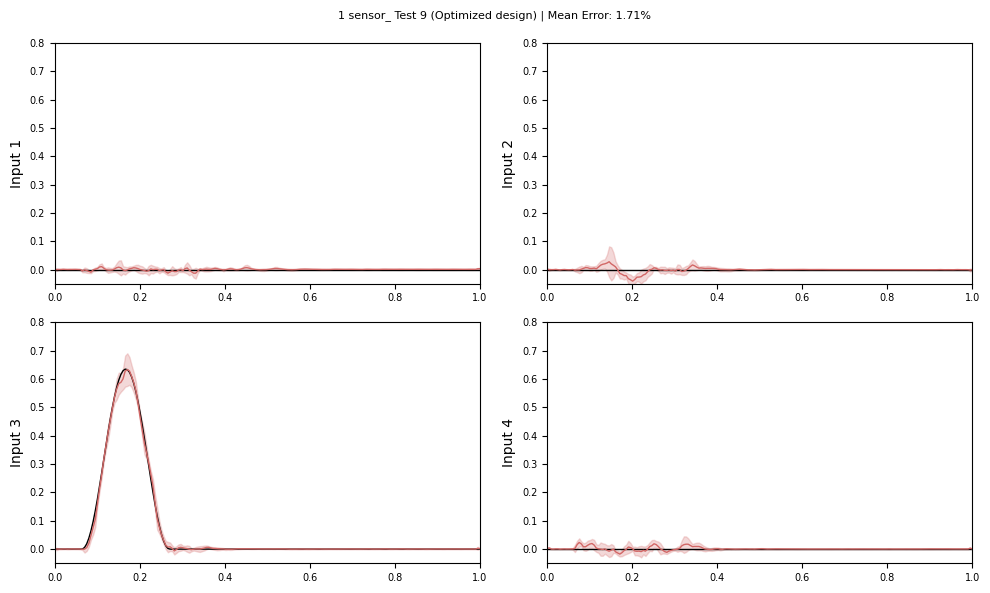

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


  Saved: Figure/4_input_source/1 sensor_Test_10_opt_band.png


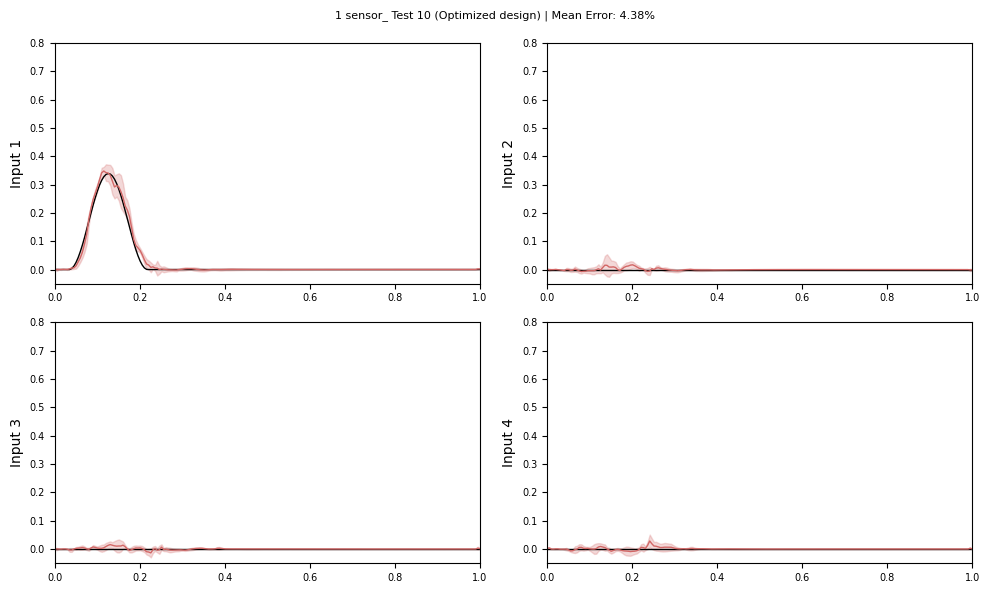

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


  Saved: Figure/4_input_source/1 sensor_Test_11_opt_band.png


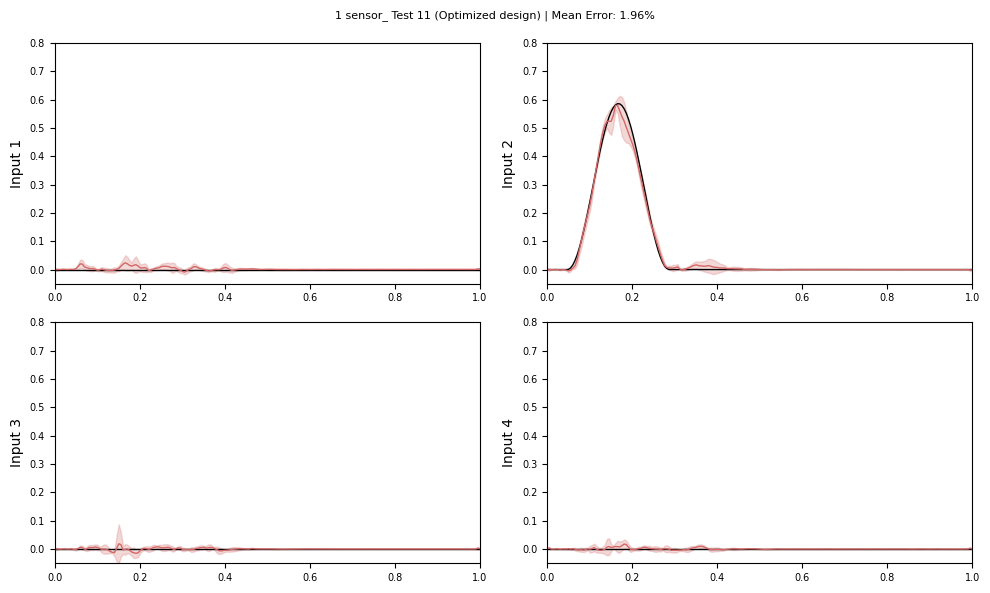

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


  Saved: Figure/4_input_source/1 sensor_Test_12_opt_band.png


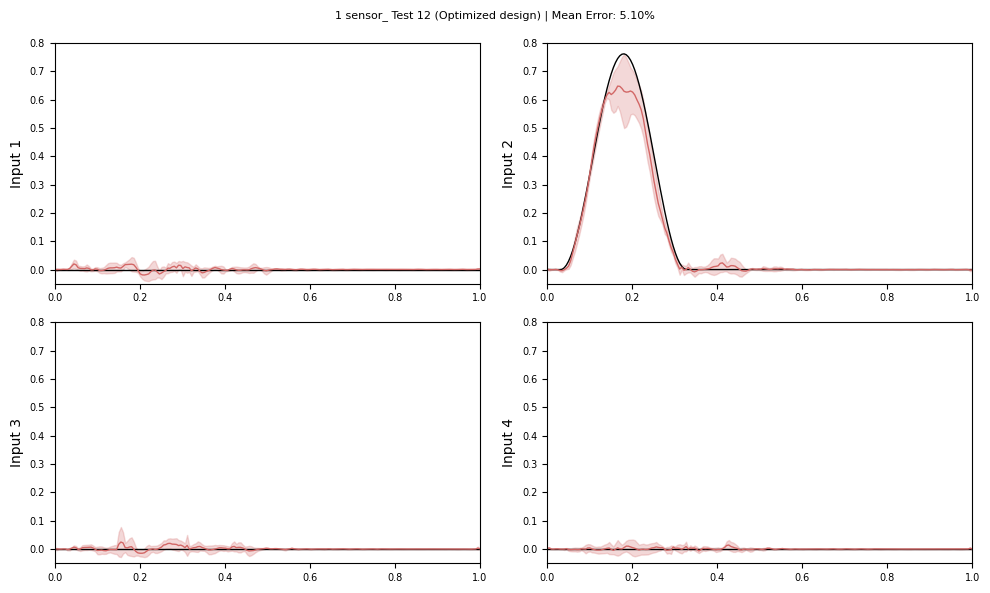

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


  Saved: Figure/4_input_source/1 sensor_Test_13_opt_band.png


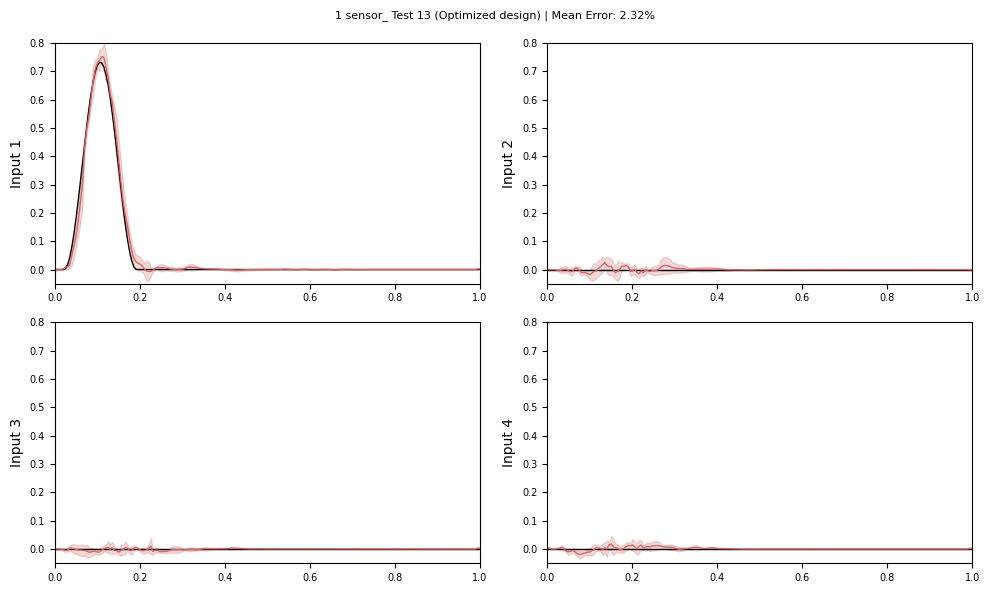

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


  Saved: Figure/4_input_source/1 sensor_Test_14_opt_band.png


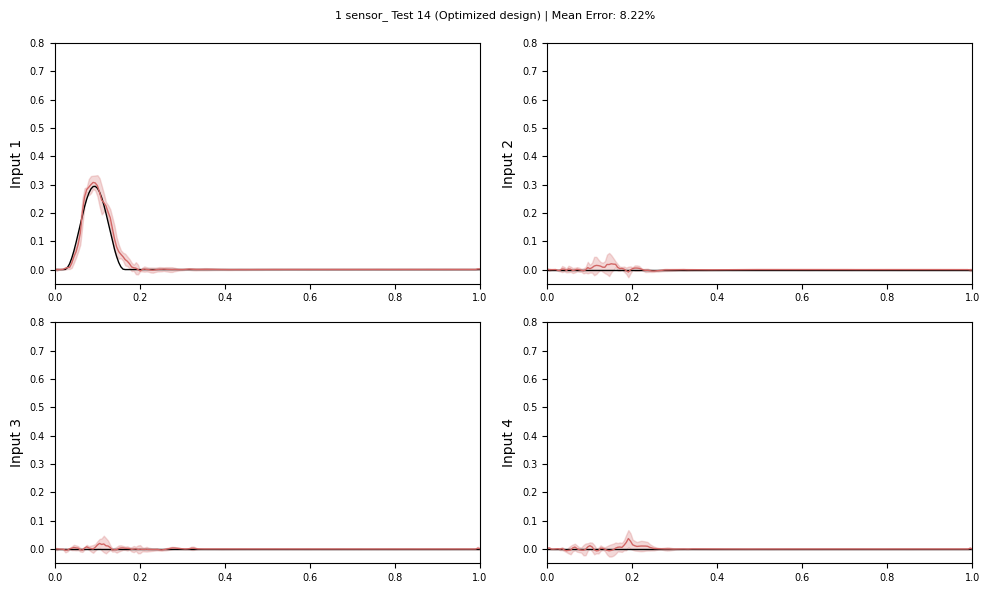

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


  Saved: Figure/4_input_source/1 sensor_Test_15_opt_band.png


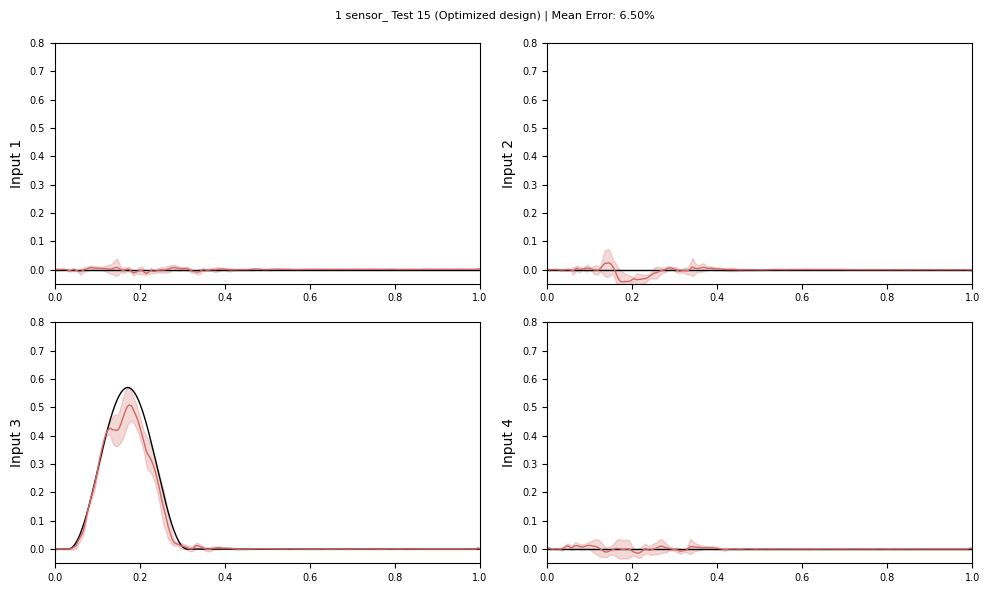

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


  Saved: Figure/4_input_source/1 sensor_Test_16_opt_band.png


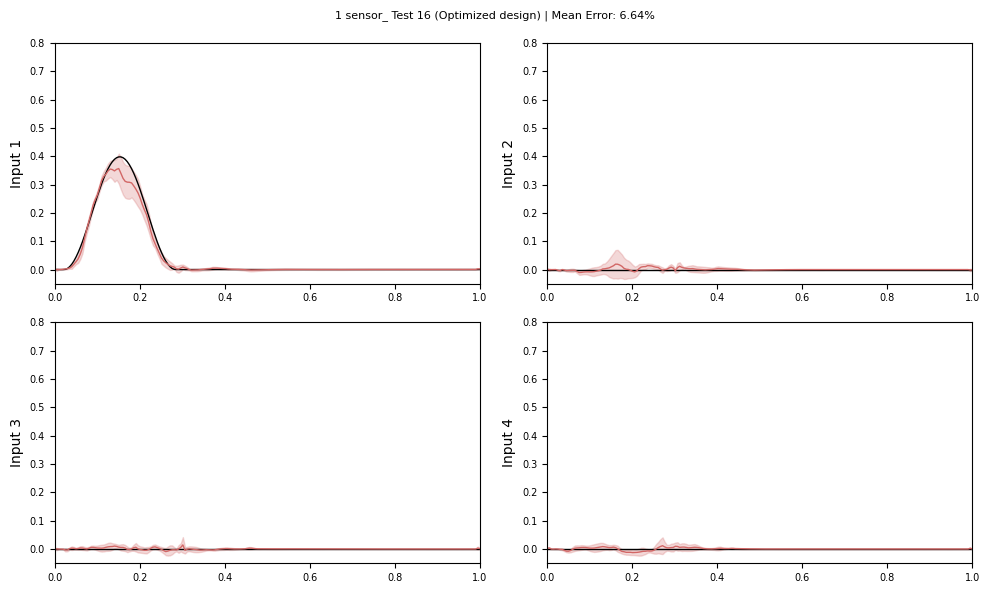

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


  Saved: Figure/4_input_source/1 sensor_Test_17_opt_band.png


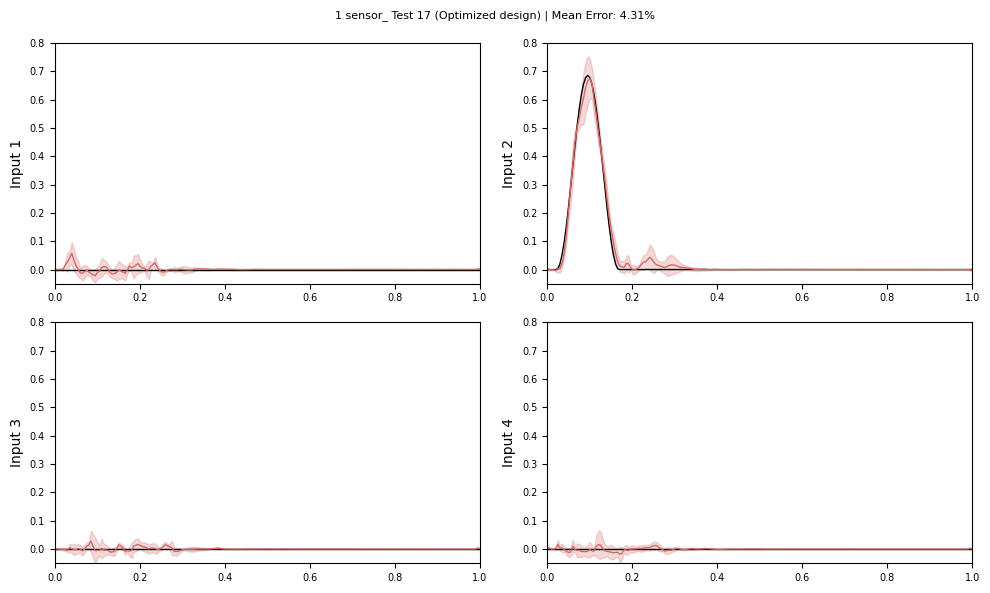

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


  Saved: Figure/4_input_source/1 sensor_Test_18_opt_band.png


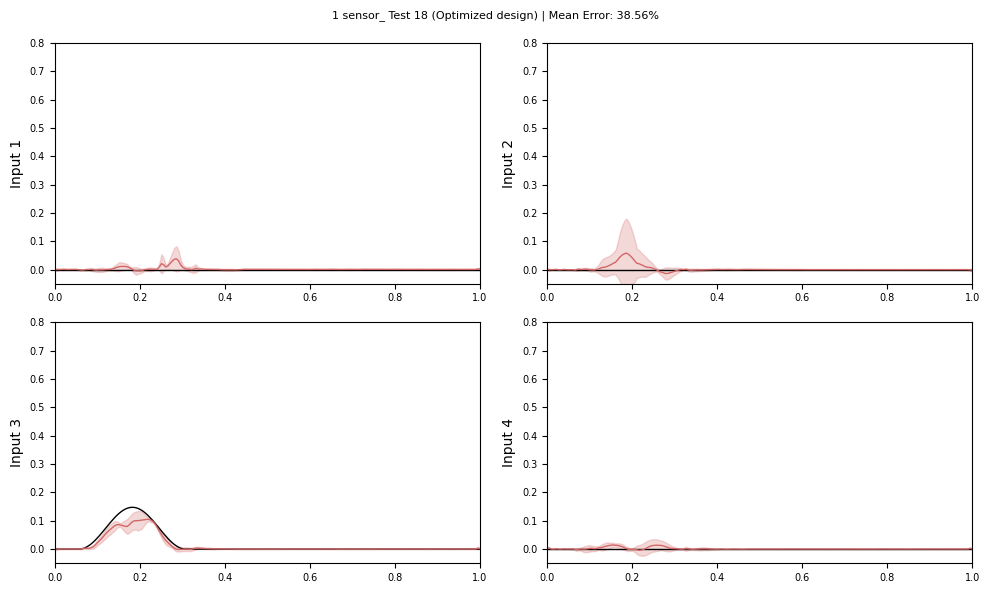

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


  Saved: Figure/4_input_source/1 sensor_Test_19_opt_band.png


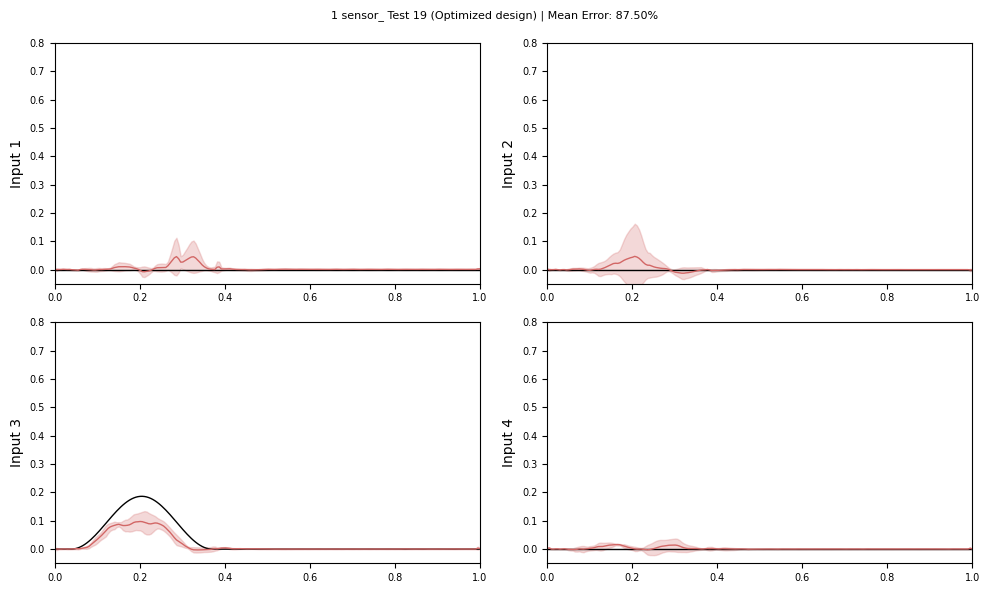

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


  Saved: Figure/4_input_source/1 sensor_Test_20_opt_band.png


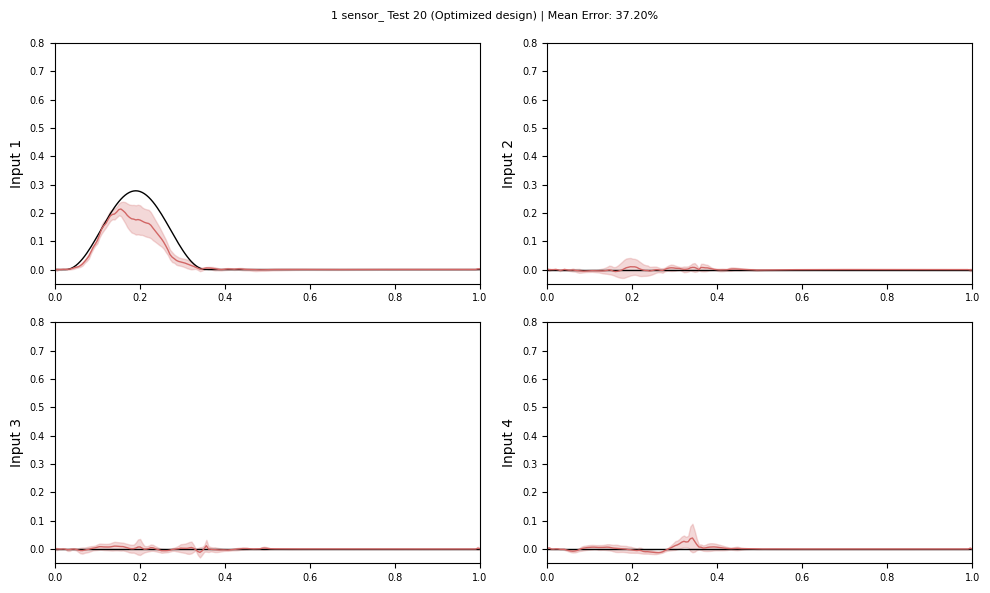

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


  Saved: Figure/4_input_source/1 sensor_Test_21_opt_band.png


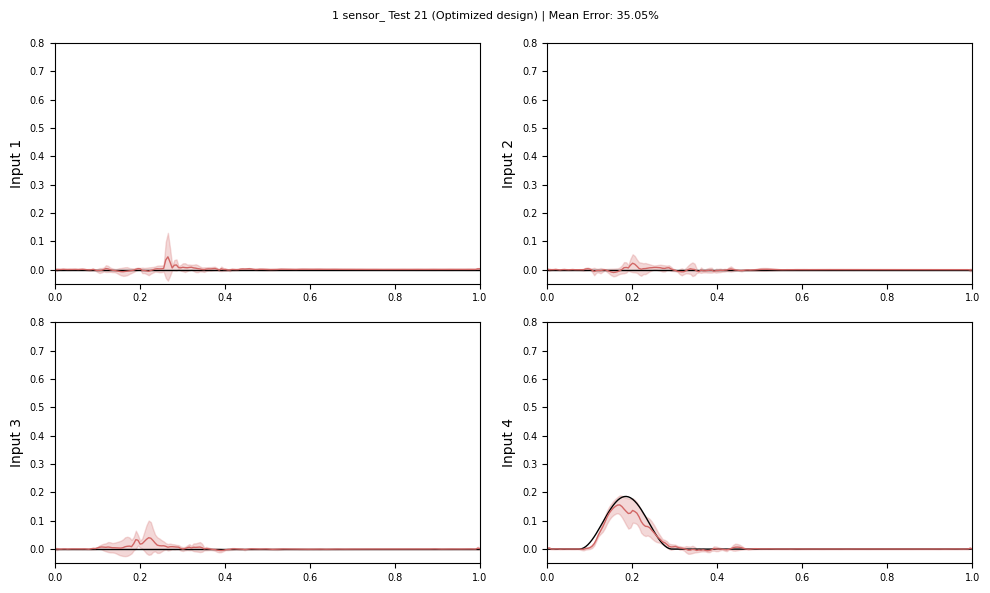

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


  Saved: Figure/4_input_source/1 sensor_Test_22_opt_band.png


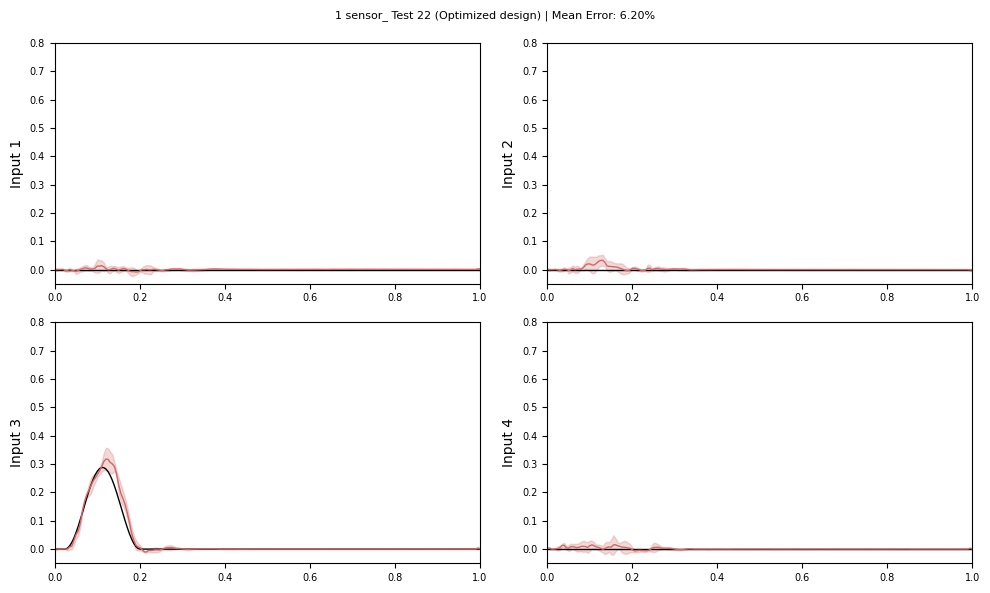

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


  Saved: Figure/4_input_source/1 sensor_Test_23_opt_band.png


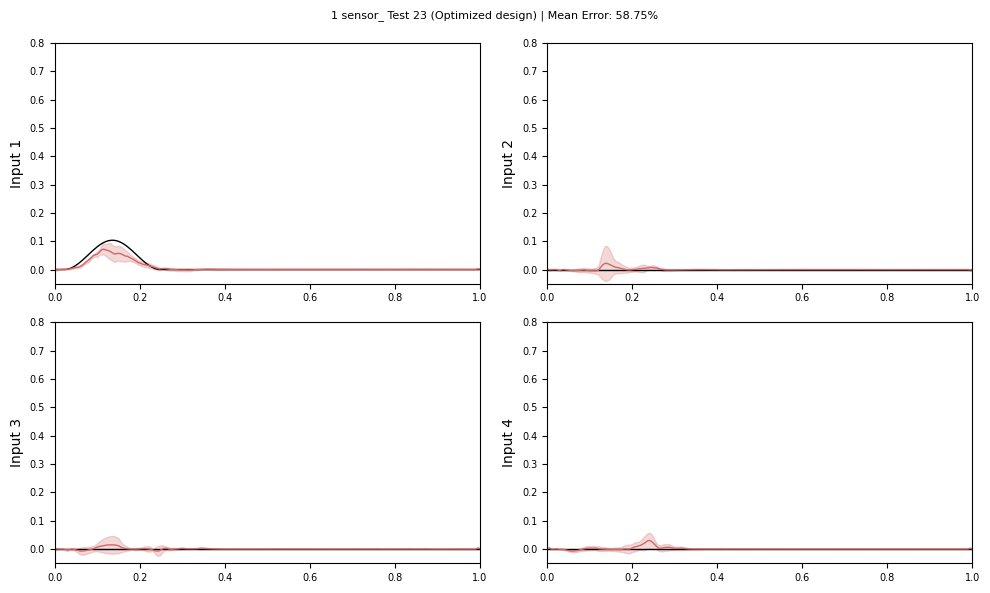

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


  Saved: Figure/4_input_source/1 sensor_Test_24_opt_band.png


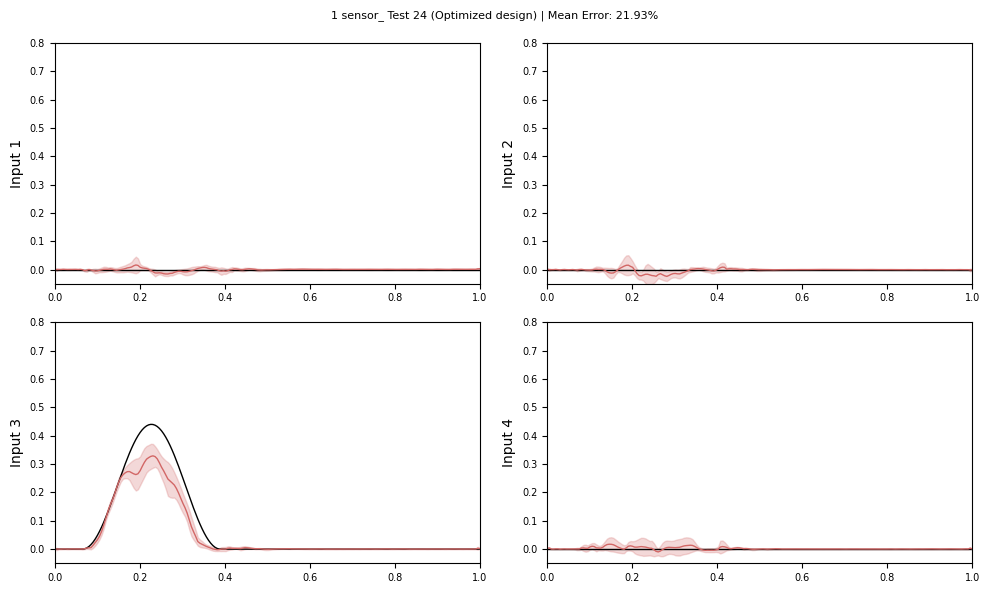

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


  Saved: Figure/4_input_source/1 sensor_Test_25_opt_band.png


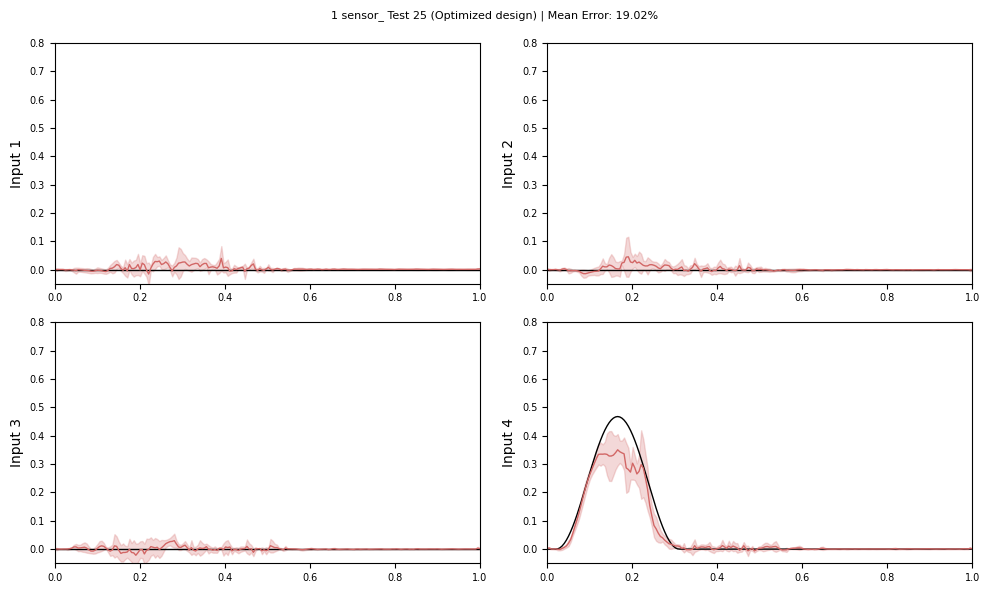

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


  Saved: Figure/4_input_source/1 sensor_Test_26_opt_band.png


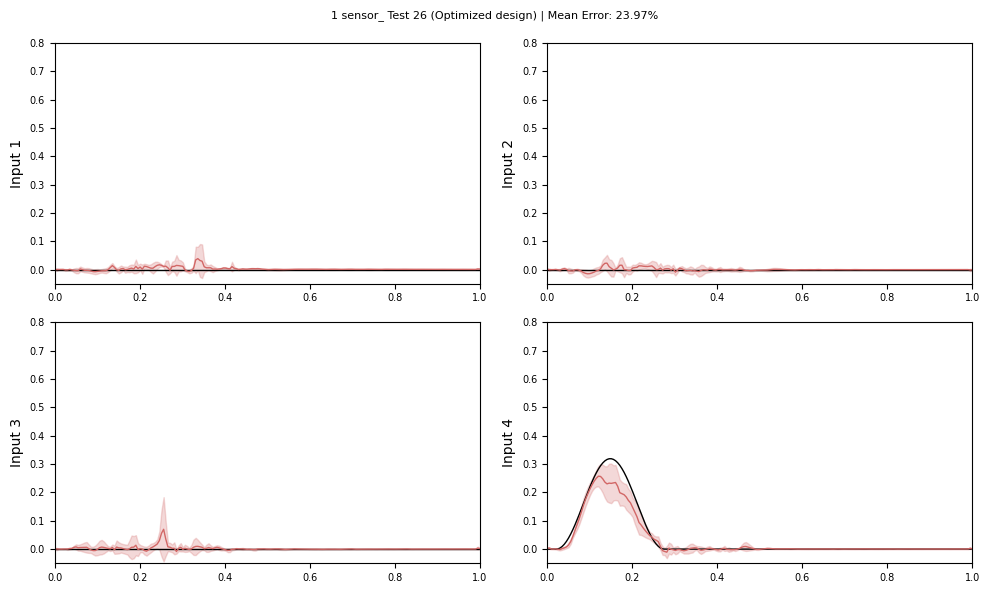

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


  Saved: Figure/4_input_source/1 sensor_Test_27_opt_band.png


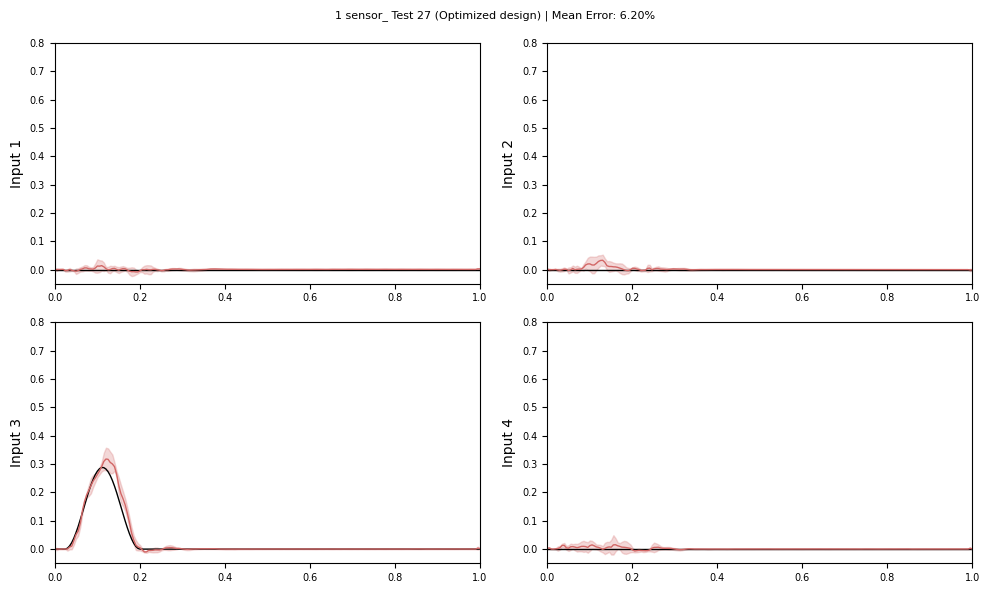

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


  Saved: Figure/4_input_source/1 sensor_Test_28_opt_band.png


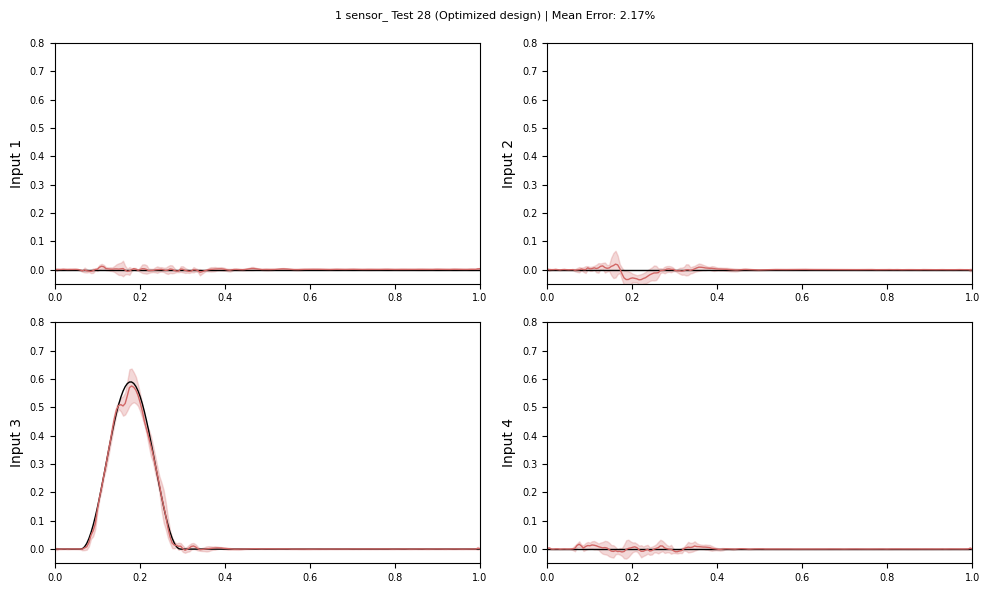

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


  Saved: Figure/4_input_source/1 sensor_Test_29_opt_band.png


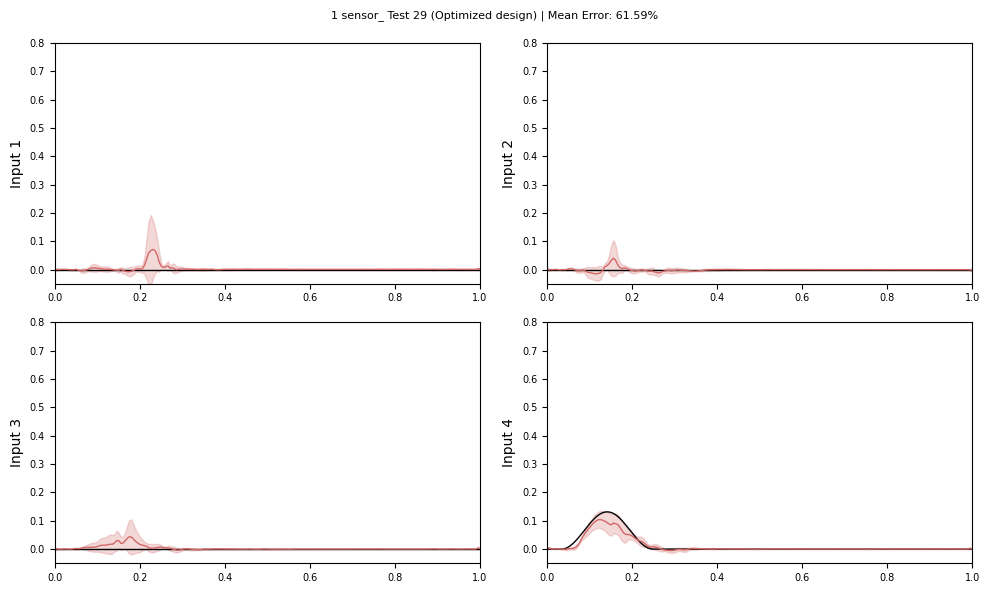

Overall mean prediction error across 30 test cases: nan%


In [31]:

configs_set = [
    [([(38,)],              ["01062026"], 0),
    ([(27,)],               ["01142026"], 0),
    ([(49,)],               ["01142026"], 0),
    ([(24,)],               ["01232026"], 0),
    ([(30,)],               ["01232026"], 0)], # 1 sensor
    # [([(25,29)],            ["01062026"], 1),
    # ([(24,41)],             ["01162026"], 1),
    # ([(35,30)],             ["01162026"], 1),
    # ([(13,30)],             ["01232026"], 1),
    # ([(19,35)],             ["01232026"], 1)], # 2 sensors
    # [([(25,29,38)],         ["01062026"], 2),
    # ([(27,35,41)],          ["01162026"], 2),
    # ([(24,30,38)],          ["01162026"], 2),
    # ([(19,27,35)],          ["01232026"], 2),
    # ([(13,27,41)],          ["01232026"], 2)], # 3 sensors
    # [([(26,28,35,41)],      ["01062026"], 3),
    # ([(24,30,37,39)],       ["01162026"], 3),
    # ([(26,28,41,46)],       ["01162026"], 3),
    # ([(15,17,37,39)],       ["01262026"], 3),
    # ([(25,29,47,51)],       ["01252026"], 3)], # 4 sensors
    # [([(25,29,34,38,42)],   ["01062026"], 4),
    # ([(23,27,31,36,40)],    ["01162026"], 4),
    # ([(23,25,27,29,31)],    ["01162026"], 4),
    # ([(24,30,35,38,41)],    ["01252026"], 4),
    # ([(13,27,30,39,46)],    ["01262026"], 4)], # 5 sensors
    # [([(13,16,19,35,38,41)], ["01062026"], 5),
    # ([(24,27,30,36,39,42)], ["01162026"], 5),
    # ([(24,27,30,47,50,53)], ["01162026"], 5),
    # ([(14,18,25,29,36,40)], ["01252026"], 5),
    # ([(25,29,36,40,47,51)], ["01252026"], 5)] # 6 sensors
]

color_list = ["#d26766", "#6bb150", "#e4c55f", "#a74f94", "#c6c72e","#f69a47"]
name_list = ["1 sensor_", "2 sensors_", "3 sensors_", "4 sensors_", "5 sensors_", "6 sensors_"]
for m in range(len(configs_set)):
    configs = configs_set[m]
    fname_list = []
    idx_list = []
    
    for idx_set, date_set, k in configs:
        for i, idx_tuple in enumerate(idx_set):
            date = date_set[i]
            idx_str = ",".join(str(x) for x in idx_tuple)
            file_idx = "_".join(str(x) for x in idx_tuple)
            fname = f"{date}_cooptimization_sim_1DCNN_data_300_n_source_4"
            if len(idx_tuple) > 0:
                fname += f"_measure_idx_{file_idx}_without_contact"
            fname += ".pickle"
        color_list_for_band = ["k", "#bdccd4", color_list[m]]

        # mm_scaler = minmax_scaler(training_input_data, training_output_data)
        # show_results(fname, N=3, save_fig=True, name=file_idx+"_")
        fname_list.append(fname)
        idx_list.append(file_idx)

    show_results_band(fname_list, N=30, save_fig=True, name=name_list[m],
                        idx_list=idx_list, source_num=4, color_list=color_list_for_band, show_off=False)